[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_09/MFM_ch9_seminar/MFM_ch9_seminar.ipynb)

# MFM_ch9_seminar

Seminar 9 computations: realised and bipower variation step by step, jump test, microstructure noise and optimal sampling, two-scale RV, log-HAR forecasts, QLIKE and MSE, Diebold-Mariano; jump tests on SPY and Bitcoin, sampling frequency with block bootstrap intervals, returns standardised by RV, log-HAR with Newey-West errors, 5-day forecasts, HAR-CJ, roughness with bootstrap intervals, and whether Bitcoin volatility is more predictable than that of the S&P 500 ETF; jump inference with Benjamini-Hochberg FDR control, intraday periodicity, Lee-Mykland, truncated RV and MedRV; Wald test of HAR as a restricted AR(22); HARQ, SHAR and the model confidence set; Giacomini-White test; realised kernel ratio with bootstrap CI; one chart per seminar exercise.

*Modelling Financial Markets (MFM), Chapter 9: Realised Volatility. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/Quantlets/Ch_09/MFM_ch9_seminar


In [2]:
# Colab: !pip install arch statsmodels
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [3]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand (gri doar pentru linii de referinta si benzi)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
MODEL_COL = {'logHAR': IDAred, 'HAR': Orange, 'GARCH-t': MainBlue, 'EWMA': Purple, 'RW': Forest}

HERE = '.'
SEED = 42
OOS_SPY = '2022-01-03'
OOS_BTC = '2025-03-01'
B_BOOT = 2000
C_START = '2025-03-01'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels:
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def ann(v, ppy):
    """Volatilitatea anualizata (%) dintr-o varianta zilnica (%^2)."""
    return np.sqrt(ppy * v)

## Realised measures, HAR and forecast evaluation

In [4]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import gamma as G

MU1 = np.sqrt(2 / np.pi)                              # E|Z|, Z ~ N(0,1)
MU43 = 2 ** (2 / 3) * G(7 / 6) / G(1 / 2)             # E|Z|^{4/3}


# =============================================================================
# ESTIMATORI REALIZATI (o valoare pe zi)
# =============================================================================
def rv(R):
    """Varianta realizata: suma patratelor randamentelor intraday."""
    return (R ** 2).sum(axis=1, min_count=1)


def nret(R):
    """Numarul de randamente intraday al fiecarei zile."""
    return R.notna().sum(axis=1)


def bv(R):
    """Variatia bipower (Barndorff-Nielsen si Shephard): robusta la salturi."""
    a = R.abs().values
    M = nret(R).values
    s = np.nansum(a[:, 1:] * a[:, :-1], axis=1)
    return pd.Series(MU1 ** -2 * M / (M - 1) * s, index=R.index)


def tq(R):
    """Tripower quarticity: estimeaza cvarticitatea integrata, robusta la salturi."""
    a = R.abs().values ** (4 / 3)
    M = nret(R).values
    s = np.nansum(a[:, 2:] * a[:, 1:-1] * a[:, :-2], axis=1)
    return pd.Series(M * MU43 ** -3 * M / (M - 2) * s, index=R.index)


def rq(R):
    """Cvarticitatea realizata (M/3) * suma r^4."""
    return nret(R) / 3 * (R ** 4).sum(axis=1)


def rv_ci(R, level=0.95):
    """Interval de incredere asimptotic pentru varianta integrata, construit pe scara log."""
    v = rv(R)
    se_log = np.sqrt(2 / 3 * (R ** 4).sum(axis=1)) / v
    z = stats.norm.ppf(0.5 + level / 2)
    return v * np.exp(-z * se_log), v * np.exp(z * se_log)


def jump_test(R, alpha=0.001):
    """Testul de salturi cu raportul (RV - BV)/RV (Huang si Tauchen); salt semnificativ daca z > z_{1-alpha}."""
    v, b, t = rv(R), bv(R), tq(R)
    M = nret(R)
    theta = MU1 ** -4 + 2 * MU1 ** -2 - 5
    z = ((v - b) / v) / np.sqrt(theta / M * np.maximum(1, t / b ** 2))
    jump = z > stats.norm.ppf(1 - alpha)
    J = np.where(jump, np.maximum(v - b, 0), 0.0)
    return pd.DataFrame({'rv': v, 'bv': b, 'tq': t, 'z': z, 'jump': jump, 'J': J, 'C': v - J})


# =============================================================================
# ZGOMOT DE MICROSTRUCTURA
# =============================================================================
def sparse_points(P, k, offset=0):
    """Preturile la fiecare al k-lea punct al grilei, pornind de la offset; deschiderea si inchiderea se pastreaza."""
    out = {}
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)
    cols = np.arange(P.shape[1])
    X = P.values
    for i, day in enumerate(P.index):
        idx = cols[(cols >= offset) & ((cols - offset) % k == 0) & (cols <= last[i])]
        idx = np.unique(np.r_[0, idx, last[i]])
        out[day] = np.log(X[i, idx])
    return out


def sparse_rv(P, k, offset=0):
    """Varianta realizata din randamente de k x 5 minute (o singura grila)."""
    pts = sparse_points(P, k, offset)
    return pd.Series({d: np.sum((100 * np.diff(x)) ** 2) for d, x in pts.items()})


def subsampled_rv(P, k):
    """Media variantelor realizate pe cele k grile decalate (esantionare rara fara pierdere de date)."""
    return pd.concat([sparse_rv(P, k, o) for o in range(k)], axis=1).mean(axis=1)


def signature(P, ks, scale):
    """Graficul semnaturii: volatilitatea anualizata medie (%) in functie de intervalul de esantionare."""
    return pd.DataFrame({
        'sparse': [np.sqrt(scale * sparse_rv(P, k).mean()) for k in ks],
        'subsampled': [np.sqrt(scale * subsampled_rv(P, k).mean()) for k in ks]}, index=list(ks))


def tsrv(P, K=6, adjust=False):
    """Two-scale realised variance (Zhang, Mykland si Ait-Sahalia): media pe K grile minus corectia de zgomot.
    Grilele pastreaza deschiderea si inchiderea, deci nbar = numarul mediu EFECTIV de randamente pe grila
    (deplasarea din zgomot a mediei este 2 nbar omega^2); adjust=True imparte la 1 - nbar/n (esantioane mici)."""
    R = 100 * np.log(P).diff(axis=1).iloc[:, 1:]
    n = nret(R)
    nbar = pd.concat([pd.Series({d: len(x) - 1 for d, x in sparse_points(P, K, o).items()}) for o in range(K)],
                     axis=1).mean(axis=1)
    ts = subsampled_rv(P, K) - nbar / n * rv(R)
    return ts / (1 - nbar / n) if adjust else ts


def noise_var(R):
    """Varianta zgomotului: omega^2 = -cov(r_i, r_{i-1}) si limita superioara RV/(2n), medii pe zile."""
    X = R.values
    cov1 = np.nanmean(X[:, 1:] * X[:, :-1])
    return {'omega2_cov': max(-cov1, 0.0), 'omega2_rv': float((rv(R) / (2 * nret(R))).mean()),
            'rho1': float(pd.Series(X[:, 1:].ravel()).corr(pd.Series(X[:, :-1].ravel())))}


def parzen(x):
    x = np.abs(x)
    return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))


def realized_kernel(R, P, c=3.5134):
    """Nucleu realizat Parzen (Barndorff-Nielsen, Hansen, Lunde si Shephard); latimea H dupa regula lor."""
    out, Hs = {}, {}
    iv20 = sparse_rv(P, 4)                                  # varianta pe grila de 20 de minute, pentru xi
    for i, day in enumerate(R.index):
        r = R.iloc[i].dropna().values
        n = len(r)
        om2 = np.sum(r ** 2) / (2 * n)
        xi2 = om2 / max(iv20[day], 1e-12)
        H = max(1, int(np.ceil(c * xi2 ** 0.4 * n ** 0.6)))
        g = [np.sum(r[h:] * r[:n - h]) for h in range(H + 1)]
        out[day] = g[0] + 2 * sum(parzen(h / (H + 1)) * g[h] for h in range(1, H + 1))
        Hs[day] = H
    return pd.Series(out), pd.Series(Hs)


# =============================================================================
# HAR-RV
# =============================================================================
def har_design(v, calendar=False):
    """Regresori HAR: componenta zilnica, saptamanala, lunara (5 si 22 de zile de tranzactionare;
    pentru cripto, pe calendar: 7 si 30 de zile, cu cel putin 5, respectiv 20 de observatii)."""
    if calendar:
        full = v.asfreq('D')
        d = full.shift(1)
        w = full.rolling(7, min_periods=5).mean().shift(1)
        m = full.rolling(30, min_periods=20).mean().shift(1)
        X = pd.DataFrame({'d': d, 'w': w, 'm': m}).reindex(v.index)
    else:
        X = pd.DataFrame({'d': v.shift(1), 'w': v.rolling(5).mean().shift(1), 'm': v.rolling(22).mean().shift(1)})
    return X


def nw_lags(T):
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def ols_nw(y, X, lags=None):
    """MCO cu termen liber si erori standard Newey-West (HAC)."""
    Xc = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    T, k = Xc.shape
    XtX_inv = np.linalg.inv(Xc.T @ Xc)
    b = XtX_inv @ Xc.T @ y
    e = y - Xc @ b
    L = nw_lags(T) if lags is None else lags
    u = Xc * e[:, None]
    S = u.T @ u
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        g = u[l:].T @ u[:-l]
        S += w * (g + g.T)
    V = XtX_inv @ S @ XtX_inv
    r2 = 1 - e @ e / np.sum((y - y.mean()) ** 2)
    return {'b': b, 'se': np.sqrt(np.diag(V)), 'V': V, 'r2': r2, 'resid': e, 'T': T, 'lags': L}


def har_fit(v, calendar=False, log=False, jumps=None):
    """HAR-RV pe esantionul complet; log=True: HAR pe log RV; jumps: componenta de salt ca regresor suplimentar."""
    X = har_design(np.log(v) if log else v, calendar)
    if jumps is not None:
        X['J'] = jumps.shift(1).reindex(X.index) if not calendar else jumps.asfreq('D').shift(1).reindex(X.index)
    y = np.log(v) if log else v
    ok = X.notna().all(axis=1)
    return ols_nw(y[ok], X[ok]), X, ok


def har_expanding(v, start, calendar=False, log=False, min_obs=100):
    """Prognoze HAR pentru ziua t, estimate zilnic pe toate observatiile anterioare lui t (fereastra extinsa)."""
    y = np.log(v) if log else v
    X = har_design(y, calendar)
    ok = X.notna().all(axis=1)
    Xv, yv = X.values, y.values
    Xc = np.column_stack([np.ones(len(X)), Xv])
    out = {}
    for t in np.where((v.index >= pd.Timestamp(start)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        if len(tr) < min_obs:
            continue
        b, *_ = np.linalg.lstsq(Xc[tr], yv[tr], rcond=None)
        f = Xc[t] @ b
        if log:
            s2 = np.var(yv[tr] - Xc[tr] @ b)
            f = np.exp(f + s2 / 2)
        out[v.index[t]] = f
    return pd.Series(out)


def har_weights(b, n=30):
    """Ponderile implicite ale HAR pe fiecare intarziere 1..n (HAR = AR(22) restrictionat)."""
    w = np.zeros(n)
    w[0] += b[1]
    w[:5] += b[2] / 5
    w[:22] += b[3] / 22
    return w


# =============================================================================
# REPERE: GARCH SI EWMA PE RANDAMENTE ZILNICE
# =============================================================================
def garch_forecasts(r, dates, refit=21, dist='t'):
    """Varianta prognozata pentru fiecare zi din dates cu GARCH(1,1), reestimat la fiecare `refit` zile
    pe toate datele anterioare; intre reestimari parametrii raman fixi, iar varianta se actualizeaza zilnic."""
    from arch import arch_model
    dates = pd.DatetimeIndex(dates)
    pos = r.index.get_indexer(dates)
    out = pd.Series(np.nan, index=dates)
    for i0 in range(0, len(dates), refit):
        blk = dates[i0:i0 + refit]
        p0 = pos[i0]
        fit = arch_model(r.iloc[:p0], mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
        fixed = arch_model(r.iloc[:pos[min(i0 + refit, len(dates)) - 1] + 1], mean='Constant', vol='GARCH', p=1, q=1,
                           dist=dist).fix(fit.params)
        out[blk] = (fixed.conditional_volatility ** 2).reindex(blk).values
    return out


def ewma_forecasts(r, lam=0.94, burn=250):
    """RiskMetrics: sigma^2_t = lambda sigma^2_{t-1} + (1 - lambda) r^2_{t-1}."""
    x = r.values
    s = np.empty(len(x))
    s[0] = np.var(x[:burn])
    for t in range(1, len(x)):
        s[t] = lam * s[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(s, index=r.index)


# =============================================================================
# EVALUAREA PROGNOZELOR
# =============================================================================
def qlike(v, f):
    """QLIKE: v/f - log(v/f) - 1 (robusta la zgomotul proxy-ului, Patton 2011)."""
    return v / f - np.log(v / f) - 1


def mse(v, f):
    return (v - f) ** 2


def dm_test(l1, l2):
    """Diebold-Mariano: d = l1 - l2; t = media(d)/se_NW; d < 0 => modelul 1 are pierdere mai mica."""
    d = (l1 - l2).dropna().values
    res = ols_nw(d, np.empty((len(d), 0)))
    t = res['b'][0] / res['se'][0]
    return {'mean_diff': float(d.mean()), 't': float(t), 'p': float(2 * stats.norm.sf(abs(t))), 'T': len(d)}


def mz_test(v, f):
    """Regresia Mincer-Zarnowitz v = a + b f + e; test Wald comun (a, b) = (0, 1) cu covarianta NW."""
    res = ols_nw(v.values, f.values[:, None])
    dlt = res['b'] - np.array([0.0, 1.0])
    W = float(dlt @ np.linalg.inv(res['V']) @ dlt)
    return {'a': res['b'][0], 'b': res['b'][1], 'se_a': res['se'][0], 'se_b': res['se'][1], 'r2': res['r2'],
            'wald': W, 'p': float(stats.chi2.sf(W, 2))}


def block_bootstrap(x, stat, block=20, B=2000, seed=42):
    """Bootstrap pe blocuri mobile (Kunsch): distributia statisticii `stat` pe serii reconstruite din blocuri."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)
        idx = (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]
        out[b] = stat(x[idx])
    return out


def block_bootstrap_blocks(x, stat, block=60, B=300, seed=42):
    """Bootstrap pe blocuri mobile care pastreaza blocurile separate: `stat` primeste o matrice (blocuri x lungime),
    astfel incat incrementele se calculeaza doar in interiorul fiecarui bloc (fara salturi artificiale la imbinari)."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x, dtype=float)
    n = len(x)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)
        out[b] = stat(x[starts[:, None] + np.arange(block)[None, :]])
    return out


# =============================================================================
# VOLATILITATE ASPRA
# =============================================================================
def roughness(logsig, qs=(0.5, 1.0, 1.5, 2.0, 3.0), lags=range(1, 31)):
    """m(q, D) = media |log sigma_{t+D} - log sigma_t|^q ~ D^{q H}: panta zeta_q = q H pe scara log-log."""
    x = np.asarray(logsig, dtype=float)             # 1D: o serie (NaN = zi lipsa); 2D: blocuri, incremente doar in bloc
    lags = np.array(list(lags))
    M = {q: np.array([np.nanmean(np.abs(x[..., l:] - x[..., :-l]) ** q) for l in lags]) for q in qs}
    zeta = {q: np.polyfit(np.log(lags), np.log(M[q]), 1)[0] for q in qs}
    H = np.polyfit(list(qs), [zeta[q] for q in qs], 1)[0] if len(qs) > 1 else zeta[qs[0]] / qs[0]
    return {'lags': lags, 'm': M, 'zeta': zeta, 'H': float(H)}

## Data

In [5]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, coloana, eticheta, 7 zile din 7?)
DAILY = {
    'spy': ('SPY.US', 'adjusted_close', 'SPY (S&P 500 ETF)', False),
    'sp500': ('GSPC.INDX', 'close', 'S&P 500', False),
    'btc': ('BTC-USD.CC', 'close', 'Bitcoin', True),
    'vix': ('VIX.INDX', 'close', 'VIX', False),
}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_intraday(symbol):
    """Citeste data/market/intraday/<SIMBOL>_5m.csv (ora UTC)."""
    fname = f'intraday/{symbol}_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    d = pd.read_csv(src, index_col='datetime_utc', parse_dates=True).sort_index()
    return d[~d.index.duplicated(keep='last')]


def daily_close(name, start=None, end=END):
    """Pretul zilnic: fara cotatii de weekend (in afara de cripto) si fara zile cu pret neschimbat (indici)."""
    symbol, col, _, all_week = DAILY[name]
    s = read_market(symbol)[col].loc[start:end]
    s = s[s > 0].dropna()
    if not all_week:
        s = s[s.index.dayofweek < 5]
    if name in ('sp500', 'vix'):
        s = s[s.diff() != 0]
    return s.rename(name)


def daily_returns(name, start=None, end=END):
    """Randamente log zilnice, in %, pe calendarul propriu al seriei."""
    return (100 * np.log(daily_close(name, start, end)).diff().dropna()).rename(name)


def spy_intraday(end=END):
    """Preturile SPY din sesiunea regulata: matrice zi x 79 de puncte (deschiderea de 09:30 + 78 de inchideri)."""
    d = read_intraday('SPY.US')
    d.index = d.index.tz_localize('UTC').tz_convert('America/New_York')
    d = d[(d.index.second == 0) & (d.index.minute % 5 == 0)]            # fara bare din afara grilei
    mins = d.index.hour * 60 + d.index.minute
    d = d[(mins >= 9 * 60 + 30) & (mins <= 15 * 60 + 55)]               # 09:30-15:55 (fara bara-ciot de 16:00)
    d = d.loc[:end + ' 23:59']
    slot = ((d.index.hour * 60 + d.index.minute) - (9 * 60 + 30)) // 5  # 0..77
    day = pd.to_datetime(d.index.date)
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': d['close'].values}).pivot(index='day', columns='slot', values='p')
    first = pd.Series(d['open'].values, index=day)[slot == 0]
    first = first[~first.index.duplicated()]
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P = P[P[0].notna() & P[-1].notna()]
    P.columns = range(P.shape[1])                                        # 0 = deschiderea, 1..78 = inchiderile barelor
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)                # ultima bara disponibila a zilei
    F = P.ffill(axis=1)                                                  # bare lipsa in interiorul zilei: pretul anterior
    F = F.where(np.arange(P.shape[1])[None, :] <= last[:, None])         # dupa inchiderea zilelor scurte: NaN
    return F


def btc_intraday(end=END, min_share=0.95):
    """Preturile Bitcoin pe zile UTC: matrice zi x 289 de puncte (deschiderea de 00:00 + 288 de inchideri)."""
    d = read_intraday('BTC-USD.CC')
    d = d[d['close'].notna() & (d['close'] > 0)].loc[:end + ' 23:59']
    g = d.resample('5min', label='left', closed='left').agg({'open': 'first', 'close': 'last'})
    have = g['close'].notna()
    day = pd.to_datetime(g.index.date)
    n = have.groupby(day).sum()
    keep = n[n >= min_share * 288].index
    g = g[day.isin(keep)]
    day = pd.to_datetime(g.index.date)
    slot = (g.index.hour * 60 + g.index.minute) // 5
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': g['close'].values}).pivot(index='day', columns='slot', values='p')
    close = close.ffill(axis=1)                                          # goluri scurte: ultimul pret cunoscut
    op = pd.DataFrame({'day': day, 'slot': slot, 'p': g['open'].values}).pivot(index='day', columns='slot', values='p')
    first = op.bfill(axis=1)[0].fillna(close[0])
    close = close.bfill(axis=1)                                          # zi care incepe cu un gol
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P.columns = range(P.shape[1])
    return P


def intraday_returns(P):
    """Randamentele log intr-o zi, in %: coloana j = intervalul (j-1, j]; NaN dupa inchiderea zilelor scurte."""
    return 100 * np.log(P).diff(axis=1).iloc[:, 1:]


def spy_overnight(P):
    """Randamentul peste noapte (%): randamentul zilnic ajustat minus randamentul deschidere-inchidere al zilei."""
    oc = 100 * np.log(P.ffill(axis=1).iloc[:, -1] / P[0])
    cc = daily_returns('spy').reindex(P.index)
    return (cc - oc).rename('overnight'), oc.rename('open_close'), cc.rename('close_close')


# ---- date folosite in toate analizele
P_SPY = spy_intraday()
R_SPY = intraday_returns(P_SPY)
ON, OC, CC = spy_overnight(P_SPY)
RV_SPY = rv(R_SPY)                       # varianta realizata intraday (%^2)
RVT_SPY = RV_SPY + ON ** 2                 # varianta zilnica totala: intraday + randamentul peste noapte la patrat
P_BTC = btc_intraday()
R_BTC = intraday_returns(P_BTC)
RV_BTC = rv(R_BTC)
D_SPY = daily_returns('spy', start='2000-01-01')
D_BTC = daily_returns('btc', start='2014-09-17')
print('SPY:', RV_SPY.index[0].date(), '->', RV_SPY.index[-1].date(), len(RV_SPY), 'days')
print('Bitcoin:', RV_BTC.index[0].date(), '->', RV_BTC.index[-1].date(), len(RV_BTC), 'days')

SPY: 2020-10-12 -> 2026-09-18 1489 days
Bitcoin: 2024-09-01 -> 2026-09-17 659 days


## Helper functions

In [6]:
A1_R = np.array([0.08, -0.15, 0.03, 0.1, -0.04, 0.12])

GW_WIN_HAR = 250
GW_WIN_GARCH = 1000

DAY = '2025-04-07'

def rough_H(logsig, qs=(0.5, 1.0, 1.5, 2.0, 3.0), lags=range(1, 31)):
    """H = panta dreptei zeta_q = q H, prin origine."""
    ro = roughness(logsig, qs, lags)
    q = np.array(qs)
    z = np.array([ro['zeta'][x] for x in qs])
    ro['H'] = float(np.sum(q * z) / np.sum(q * q))
    return ro

## Analysis

In [7]:
def a1_rv_bv(r=A1_R):
    """RV, BV si ponderea variatiei nediscutate de BV pentru sase randamente de 5 minute (%)."""
    M_ = len(r)
    v = np.sum(r ** 2)
    s = np.sum(np.abs(r[1:]) * np.abs(r[:-1]))
    b = (np.pi / 2) * M_ / (M_ - 1) * s
    sparse = np.sum(np.array([r[:3].sum(), r[3:].sum()]) ** 2)
    return {'rv': v, 's': s, 'bv': b, 'ratio': (v - b) / v, 'sparse15': sparse,
            'vol_ann': np.sqrt(252 * v * 78 / M_), 'sq': list(r ** 2), 'prod': list(np.abs(r[1:]) * np.abs(r[:-1]))}


def a2_jump(r=A1_R):
    """Aceleasi randamente, dar ultimul este un salt de -0,90%: RV, BV, statistica raportului."""
    x = r.copy()
    x[-1] = -0.90
    out = a1_rv_bv(x)
    M_ = len(x)
    a43 = np.abs(x) ** (4 / 3)
    tq = M_ * MU43 ** -3 * M_ / (M_ - 2) * np.sum(a43[2:] * a43[1:-1] * a43[:-2])
    theta = MU1 ** -4 + 2 * MU1 ** -2 - 5
    z = out['ratio'] / np.sqrt(theta / M_ * max(1, tq / out['bv'] ** 2))
    out.update({'tq': tq, 'theta': theta, 'z': z, 'crit': stats.norm.ppf(0.999), 'jump_part': out['rv'] - out['bv']})
    return out


def a3_noise(iv=1.0, omega=0.01):
    """Bias-ul zgomotului: E[RV] = IV + 2 n omega^2; frecventa optima n* = (IQ / (4 omega^4))^(1/3) cu IQ = IV^2."""
    rows = {n: {'bias': 2 * n * omega ** 2, 'erv': iv + 2 * n * omega ** 2} for n in (78, 390, 23400)}
    nstar = (iv ** 2 / (4 * omega ** 4)) ** (1 / 3)
    return {'rows': rows, 'nstar': nstar, 'secs': 23400 / nstar, 'omega2': omega ** 2}


def a4_tsrv(rv_all=1.70, rv_avg=1.10, n=390, K=5, iv=1.0):
    """Actiune BVB mai putin lichida: omega = 0,03%; TSRV din RV pe 1 minut si media pe 5 grile de 5 minute."""
    om = 0.03
    nbar = (n - K + 1) / K
    ts = rv_avg - nbar / n * rv_all
    return {'bias5': 2 * 78 * om ** 2, 'bias1': 2 * n * om ** 2, 'nstar': (iv ** 2 / (4 * om ** 4)) ** (1 / 3),
            'secs': 23400 / (iv ** 2 / (4 * om ** 4)) ** (1 / 3), 'nbar': nbar, 'ratio': nbar / n, 'tsrv': ts,
            'tsrv_adj': ts / (1 - nbar / n), 'omega2_hat': (rv_all - iv) / (2 * n)}


def a5_har(b=(-0.08, 0.36, 0.34, 0.17), d=np.log(2.0), w=np.log(1.2), m=np.log(0.9)):
    """Prognoza log-HAR pentru maine; ponderi implicite pe intarzieri; persistenta."""
    lf = b[0] + b[1] * d + b[2] * w + b[3] * m
    return {'lf': lf, 'f': np.exp(lf), 'w1': b[1] + b[2] / 5 + b[3] / 22, 'w2': b[2] / 5 + b[3] / 22, 'w6': b[3] / 22,
            'pers': b[1] + b[2] + b[3], 'geo_mean': np.exp(b[0] / (1 - sum(b[1:]))), 'd': d, 'w': w, 'm': m}


def a6_losses():
    """QLIKE si MSE pentru doua prognoze pe trei zile."""
    v = np.array([0.8, 1.5, 0.6])
    fa = np.array([1.0, 1.0, 1.0])
    fb = np.array([0.6, 1.6, 0.4])
    out = {}
    for k, f in [('A', fa), ('B', fb)]:
        q = v / f - np.log(v / f) - 1
        e = (v - f) ** 2
        out[k] = {'q': list(q), 'qm': q.mean(), 'e': list(e), 'em': e.mean()}
    # prognoza de 2 ori prea mica vs de 2 ori prea mare (v = 1)
    out['under'] = 1 / 0.5 - np.log(1 / 0.5) - 1
    out['over'] = 1 / 2.0 - np.log(1 / 2.0) - 1
    out['under_mse'] = (1 - 0.5) ** 2
    out['over_mse'] = (1 - 2.0) ** 2
    return out


def a7_har2(b=(-0.08, 0.36, 0.34, 0.17), days=(2.0, 1.6, 1.3, 1.1, 1.0), m=0.9):
    """Prognoza log-HAR pe doua zile, iterativ: prognoza de maine devine valoare 'observata' pentru poimaine."""
    L = np.log(np.array(days))           # log RV pe ultimele 5 zile (azi primul)
    lm = np.log(m)
    f1 = b[0] + b[1] * L[0] + b[2] * L.mean() + b[3] * lm
    L2 = np.r_[f1, L[:4]]
    lm2 = (21 * lm + f1) / 22            # aproximatie: media lunara actualizata cu noua valoare
    f2 = b[0] + b[1] * f1 + b[2] * L2.mean() + b[3] * lm2
    return {'lw': L.mean(), 'f1': f1, 'F1': np.exp(f1), 'lw2': L2.mean(), 'lm2': lm2, 'f2': f2, 'F2': np.exp(f2), 'lm': lm}


def a8_dm(mean_d=-0.0327, se=0.0142, b=0.70, se_b=0.24, a=0.24, se_a=0.23):
    """Statistica DM din media diferentelor de pierdere si eroarea ei HAC; testele MZ separate pentru a si b."""
    t = mean_d / se
    return {'t': t, 'p': 2 * stats.norm.sf(abs(t)), 'tb': (b - 1) / se_b, 'ta': a / se_a,
            'pb': 2 * stats.norm.sf(abs((b - 1) / se_b)), 'pa': 2 * stats.norm.sf(abs(a / se_a))}


def b1_spy_jumps():
    """Testul de salturi pe SPY la trei niveluri; ora celui mai mare randament in zilele cu salt."""
    j = jump_test(R_SPY)
    out = {'N': int(len(j))}
    for a, tag in [(0.05, '5'), (0.01, '1'), (0.001, '0_1')]:
        k = int((j['z'] > stats.norm.ppf(1 - a)).sum())
        out[f'n{tag}'] = k
        out[f'share{tag}'] = k / len(j)
        out[f'exp{tag}'] = a * len(j)
    jd = j[j['jump']].index
    slot = R_SPY.loc[jd].abs().idxmax(axis=1).astype(int)          # coloana 1..78 = intervalul care se termina la 09:30 + 5*col
    end = pd.Timestamp('2000-01-01 09:30') + pd.to_timedelta(5 * slot.values, unit='min')
    hours = pd.Series([t.strftime('%H:%M') for t in end], index=jd)
    at10 = float(np.mean([(t.hour == 10 and t.minute <= 5) for t in end]))
    at14 = float(np.mean([(t.hour == 14 and t.minute <= 5) or (t.hour == 14 and t.minute == 0) for t in end]))
    fig, ax = plt.subplots(figsize=(8.2, 3.0))
    mins = np.array([(t.hour - 9) * 60 + t.minute - 30 for t in end])
    ax.hist(mins, bins=np.arange(0, 391, 15), color=MainBlue, label='Days with a significant jump: time of the largest 5-minute return')
    ax.set_xticks([0, 30, 90, 150, 210, 270, 330, 390])
    ax.set_xticklabels(['09:30', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00'])
    ax.set_ylabel('Number of days')
    legend_outside_bottom(ax, ncol=1, y=-0.15)
    save_fig('ch9_sem_jump_times')
    top = j.sort_values('z', ascending=False).head(3)
    out.update({'at10': at10, 'at14': at14, 'n_jump': int(len(jd)),
                'top': [{'date': str(d.date()), 'z': float(r['z']), 'jshare': float(r['J'] / r['rv']),
                         'time': hours[d]} for d, r in top.iterrows()],
                'jshare': float(j['J'].sum() / j['rv'].sum()), 'z_mean': float(j['z'].mean()), 'z_sd': float(j['z'].std())})
    return out


def b2_btc_jumps():
    """Testul de salturi pe Bitcoin; zilele de weekend vs zilele lucratoare."""
    j = jump_test(R_BTC)
    wk = j.index.dayofweek >= 5
    return {'N': int(len(j)), 'n': int(j['jump'].sum()), 'share': float(j['jump'].mean()),
            'share_we': float(j.loc[wk, 'jump'].mean()), 'share_wd': float(j.loc[~wk, 'jump'].mean()),
            'jshare': float(j['J'].sum() / j['rv'].sum()), 'exp': 0.001 * len(j),
            'p_binom': float(stats.binomtest(int(j['jump'].sum()), len(j), 0.001, alternative='greater').pvalue),
            'bv_rv_we': float((j.loc[wk, 'bv'] / j.loc[wk, 'rv']).mean()),
            'bv_rv_wd': float((j.loc[~wk, 'bv'] / j.loc[~wk, 'rv']).mean()),
            'z_zero_share': float((R_BTC == 0).mean().mean())}


def b3_frequency():
    """SPY: RV la 5, 15, 30 si 65 de minute; bootstrap pe blocuri pentru raportul mediilor; putere predictiva."""
    base = RV_SPY
    out = {}
    fig, ax = plt.subplots(figsize=(8.2, 3.0))
    for k, col in [(1, MainBlue), (3, Forest), (6, Amber), (13, IDAred)]:
        v = sparse_rv(P_SPY, k)
        vs = subsampled_rv(P_SPY, k)
        ratio = v.mean() / base.mean()
        boot = block_bootstrap(np.c_[v.values, base.values], lambda x: x[:, 0].mean() / x[:, 1].mean(), 20, B_BOOT, SEED)
        lv = np.log(v)
        nxt = np.log(base).shift(-1)
        c = pd.concat([lv, nxt], axis=1).dropna().corr().iloc[0, 1]
        rel = np.log(v / base)
        out[str(5 * k)] = {'vol': float(ann(v.mean(), 252)), 'vol_sub': float(ann(vs.mean(), 252)), 'ratio': float(ratio),
                           'lo': float(np.percentile(boot, 2.5)), 'hi': float(np.percentile(boot, 97.5)),
                           'corr_next': float(c), 'sd_rel': float(rel.std()),
                           'corr_next_sub': float(pd.concat([np.log(vs), nxt], axis=1).dropna().corr().iloc[0, 1])}
        if k > 1:
            ax.hist(rel.clip(-2, 2), bins=np.linspace(-2, 2, 61), histtype='step', color=col, lw=1.3,
                    label=f'log(RV at {5 * k} min / RV at 5 min)')
    ax.set_xlabel('Log ratio to the 5-minute RV, same day')
    ax.set_ylabel('Number of days')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch9_sem_frequency')
    return out


def b4_standardised():
    """Randamente standardizate cu RV (Andersen, Bollerslev, Diebold si Labys): aplatizare cu interval bootstrap."""
    out = {}
    btc_oc = 100 * np.log(P_BTC.iloc[:, -1] / P_BTC[0])
    for k, r, v in [('spy', OC, RV_SPY), ('btc', btc_oc, RV_BTC)]:
        z = (r / np.sqrt(v)).values
        u = (r / r.std()).values
        kz = block_bootstrap(z, lambda x: stats.kurtosis(x) + 3, 20, B_BOOT, SEED)
        ku = block_bootstrap(u, lambda x: stats.kurtosis(x) + 3, 20, B_BOOT, SEED)
        out[k] = {'kz': float(stats.kurtosis(z) + 3), 'kz_lo': float(np.percentile(kz, 2.5)), 'kz_hi': float(np.percentile(kz, 97.5)),
                  'ku': float(stats.kurtosis(u) + 3), 'ku_lo': float(np.percentile(ku, 2.5)), 'ku_hi': float(np.percentile(ku, 97.5)),
                  'sdz': float(z.std()), 'jbz': float(stats.jarque_bera(z).statistic), 'jbz_p': float(stats.jarque_bera(z).pvalue),
                  'skz': float(stats.skew(z)), 'N': int(len(z)),
                  'tail3': float(np.mean(np.abs(z) > 3)), 'tail3u': float(np.mean(np.abs(u) > 3))}
    out['normal_tail3'] = float(2 * stats.norm.sf(3))
    return out


def b5_har_insample():
    """log-HAR pe SPY (varianta totala), MCO cu erori obisnuite si Newey-West; Wald: beta_w = beta_m; Ljung-Box pe reziduuri."""
    res, X, ok = har_fit(RVT_SPY, log=True)
    y = np.log(RVT_SPY)[ok]
    Xc = np.column_stack([np.ones(ok.sum()), X[ok].values])
    e = res['resid']
    s2 = e @ e / (len(e) - 4)
    se_ols = np.sqrt(np.diag(s2 * np.linalg.inv(Xc.T @ Xc)))
    R = np.array([0, 0, 1, -1.0])
    wald = float((R @ res['b']) ** 2 / (R @ res['V'] @ R))
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(e, lags=[10, 22])
    lb2 = acorr_ljungbox(y.values - y.mean(), lags=[10, 22])
    ar1 = ols_nw(y.values[1:], y.values[:-1, None])
    return {'b': res['b'], 'se_nw': res['se'], 'se_ols': se_ols, 'r2': res['r2'], 'T': res['T'], 'lags': res['lags'],
            'wald_wm': wald, 'p_wm': float(stats.chi2.sf(wald, 1)), 'lb10': float(lb['lb_stat'].iloc[0]), 'lb10_p': float(lb['lb_pvalue'].iloc[0]),
            'lb22': float(lb['lb_stat'].iloc[1]), 'lb22_p': float(lb['lb_pvalue'].iloc[1]), 'lby22': float(lb2['lb_stat'].iloc[1]),
            'pers': float(sum(res['b'][1:])), 'ar1_b': float(ar1['b'][1]), 'ar1_r2': float(ar1['r2']),
            't_nw': list(res['b'] / res['se']), 'ratio_se': list(res['se'] / se_ols)}


def garch_params_blocks(r, dates, refit=21, window=None):
    """Parametrii GARCH(1,1)-t reestimati la fiecare `refit` zile si varianta conditionata pentru fiecare zi;
    window=None: fereastra extinsa (toate randamentele anterioare); window=m: ultimele m randamente (fereastra mobila)."""
    from arch import arch_model
    dates = pd.DatetimeIndex(dates)
    pos = r.index.get_indexer(dates)
    rows = []
    for i0 in range(0, len(dates), refit):
        blk = dates[i0:i0 + refit]
        s0 = 0 if window is None else max(0, pos[i0] - window)
        fit = arch_model(r.iloc[s0:pos[i0]], mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
        fixed = arch_model(r.iloc[s0:pos[min(i0 + refit, len(dates)) - 1] + 1], mean='Constant', vol='GARCH', p=1, q=1,
                           dist='t').fix(fit.params)
        s2 = (fixed.conditional_volatility ** 2).reindex(blk)
        for d in blk:
            rows.append((d, s2[d], fit.params['omega'], fit.params['alpha[1]'], fit.params['beta[1]']))
    return pd.DataFrame(rows, columns=['date', 's2', 'omega', 'alpha', 'beta']).set_index('date')


def b6_week():
    """Prognoza variantei pe urmatoarele 5 zile (SPY): HAR direct pe log vs GARCH(1,1)-t cu formula pe h pasi."""
    v = RVT_SPY
    y5 = v[::-1].rolling(5).sum()[::-1]                     # suma RV pe zilele t..t+4 (tinta pentru prognoza facuta la t-1)
    X = har_design(np.log(v))
    ok = X.notna().all(axis=1) & y5.notna()
    Xc = np.column_stack([np.ones(len(X)), X.values])
    ly = np.log(y5).values
    idx = np.where((v.index >= pd.Timestamp('2022-01-03')) & ok.values)[0]
    fh = {}
    for t in idx:
        tr = np.where(ok.values[:t - 4])[0]                 # doar tinte complet observate inainte de t
        b, *_ = np.linalg.lstsq(Xc[tr], ly[tr], rcond=None)
        s2 = np.var(ly[tr] - Xc[tr] @ b)
        fh[v.index[t]] = np.exp(Xc[t] @ b + s2 / 2)
    fh = pd.Series(fh)
    G = garch_params_blocks(D_SPY, fh.index)
    pers = G['alpha'] + G['beta']
    lr = G['omega'] / (1 - pers)
    fg = sum(lr + pers ** h * (G['s2'] - lr) for h in range(5))
    yy = y5.reindex(fh.index)
    out = {'T': int(len(fh))}
    for k, f in [('har', fh), ('garch', fg)]:
        mz = mz_test(yy, f)
        out[k] = {'qlike': float(qlike(yy, f).mean()), 'mse': float(mse(yy, f).mean()), 'mz_b': mz['b'], 'mz_a': mz['a'],
                  'mz_r2': mz['r2'], 'mz_p': mz['p'], 'mz_se_b': mz['se_b']}
    dq = dm_test(qlike(yy, fh), qlike(yy, fg))
    out.update({'dm_t': dq['t'], 'dm_p': dq['p'], 'pers_med': float(pers.median()),
                'note_overlap': 'overlapping 5-day targets: HAC lags set by the rule of thumb'})
    return out


def b7_harcj():
    """HAR-CJ pe log (Andersen, Bollerslev si Diebold, 2007): tinta ln(varianta totala a zilei t), regresori din ziua t-1;
    in esantion (Newey-West) si out-of-sample."""
    j = jump_test(R_SPY)
    C = j['C'] + ON ** 2                                    # partea continua a variantei totale (noaptea inclusa)
    Jc = j['J']
    v = RVT_SPY
    # specificatia pe log din Andersen, Bollerslev si Diebold (2007): log al mediilor aritmetice ale lui C si
    # log(1 + J) pentru componentele de salt zilnica, saptamanala si lunara; toate cunoscute in seara zilei t-1
    X = pd.DataFrame({'cd': np.log(C).shift(1), 'cw': np.log(C.rolling(5).mean()).shift(1),
                      'cm': np.log(C.rolling(22).mean()).shift(1), 'jd': np.log1p(Jc).shift(1),
                      'jw': np.log1p(Jc.rolling(5).mean()).shift(1), 'jm': np.log1p(Jc.rolling(22).mean()).shift(1)})
    y = np.log(v)
    ok = X.notna().all(axis=1)
    res = ols_nw(y[ok], X[ok])
    base, *_ = har_fit(v, log=True)
    # out-of-sample de la 2022, fereastra extinsa
    Xc = np.column_stack([np.ones(len(X)), X.values])
    f = {}
    for t in np.where((v.index >= pd.Timestamp('2022-01-03')) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        b, *_ = np.linalg.lstsq(Xc[tr], y.values[tr], rcond=None)
        f[v.index[t]] = np.exp(Xc[t] @ b + np.var(y.values[tr] - Xc[tr] @ b) / 2)
    f = pd.Series(f)
    fl = har_expanding(v, '2022-01-03', log=True).reindex(f.index)
    yy = v.reindex(f.index)
    dq = dm_test(qlike(yy, f), qlike(yy, fl))
    Rj = np.zeros((3, 7))
    Rj[0, 4] = Rj[1, 5] = Rj[2, 6] = 1.0                   # H0: beta_Jd = beta_Jw = beta_Jm = 0
    dj = Rj @ res['b']
    wj = float(dj @ np.linalg.solve(Rj @ res['V'] @ Rj.T, dj))
    return {'b': res['b'], 'se': res['se'], 'r2': res['r2'], 'r2_base': base['r2'], 'T': res['T'],
            'wald_j': wj, 'p_j': float(stats.chi2.sf(wj, 3)),
            'q_cj': float(qlike(yy, f).mean()), 'q_har': float(qlike(yy, fl).mean()), 'dm_t': dq['t'], 'dm_p': dq['p']}


def b8_rough():
    """Exponentul H al log-volatilitatii (SPY): RV totala, RV intraday, BV, RV subesantionata la 30 de minute; bootstrap pe blocuri."""
    series = {'rv_total': RVT_SPY, 'rv_intraday': RV_SPY, 'bv': bv(R_SPY), 'rv30_sub': subsampled_rv(P_SPY, 6)}
    out = {}
    for k, s in series.items():
        x = 0.5 * np.log(s.values)
        H = rough_H(x)['H']
        boot = block_bootstrap_blocks(x, lambda z: rough_H(z)['H'], 60, 300, SEED)
        out[k] = {'H': H, 'lo': float(np.percentile(boot, 2.5)), 'hi': float(np.percentile(boot, 97.5))}
    # H pentru un proces cu H = 0.5 masurat cu zgomot (simulare): cat de mult coboara estimarea?
    rng = np.random.default_rng(SEED)
    n = len(RVT_SPY)
    x = np.cumsum(0.1 * rng.standard_normal(n))
    x = x - np.linspace(0, x[-1], n)
    out['sim_bm'] = rough_H(x)['H']
    out['sim_bm_noise'] = rough_H(x + 0.25 * rng.standard_normal(n))['H']
    return out


def oos_forecasts(v, r, start, calendar):
    """Prognoze pentru ziua urmatoare: HAR, log-HAR (fereastra extinsa), GARCH(1,1)-t si EWMA pe randamente zilnice, RV de ieri."""
    idx = v.loc[start:].index
    F = pd.DataFrame({
        'logHAR': har_expanding(v, start, calendar=calendar, log=True),
        'HAR': har_expanding(v, start, calendar=calendar),
        'GARCH-t': garch_forecasts(r, idx),
        'EWMA': ewma_forecasts(r).reindex(idx),
        'RW': (v.asfreq('D').shift(1).reindex(idx) if calendar else v.shift(1).reindex(idx))}).dropna()
    return F, v.reindex(F.index)


def c1_predictability():
    """Aceeasi perioada out-of-sample (martie 2025 - septembrie 2026): log-HAR, GARCH-t, RV de ieri; R^2 MZ,
    castigul QLIKE fata de RV de ieri, bootstrap pe blocuri pentru diferenta de R^2; log-HAR cu efect de weekend pentru Bitcoin."""
    F = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_spy.csv'), index_col=0, parse_dates=True).loc[C_START:]
    Fb = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_btc.csv'), index_col=0, parse_dates=True).loc[C_START:]
    out = {}
    for k, D in [('spy', F), ('btc', Fb)]:
        y = D['proxy']
        o = {'T': int(len(D))}
        for m in ['logHAR', 'GARCH-t', 'RW']:
            o[m] = {'r2': mz_test(y, D[m])['r2'], 'qlike': float(qlike(y, D[m]).mean())}
            o[m]['r2log'] = float(np.corrcoef(np.log(y), np.log(D[m]))[0, 1] ** 2)
        o['gain_rw'] = 1 - o['logHAR']['qlike'] / o['RW']['qlike']
        o['gain_garch'] = 1 - o['logHAR']['qlike'] / o['GARCH-t']['qlike']
        out[k] = o
    # bootstrap pe blocuri pentru diferenta R^2 (pe log) intre Bitcoin si SPY: aceleasi blocuri de timp calendaristic
    # (28 de zile, circa 20 de zile de tranzactionare SPY) pentru ambele active, deci covarianta dintre ele se pastreaza
    a = np.c_[np.log(F['proxy']), np.log(F['logHAR'])]
    b = np.c_[np.log(Fb['proxy']), np.log(Fb['logHAR'])]
    cal = pd.date_range(min(F.index[0], Fb.index[0]), max(F.index[-1], Fb.index[-1]), freq='D')
    rowa = np.full(len(cal), -1)
    rowa[cal.get_indexer(F.index)] = np.arange(len(F))
    rowb = np.full(len(cal), -1)
    rowb[cal.get_indexer(Fb.index)] = np.arange(len(Fb))
    rng = np.random.default_rng(SEED)
    block, ncal = 28, len(cal)
    nb = int(np.ceil(ncal / block))

    def r2(x, rows):
        rows = rows[rows >= 0]
        return np.corrcoef(x[rows, 0], x[rows, 1])[0, 1] ** 2
    d = np.empty(B_BOOT)
    for i in range(B_BOOT):
        st = rng.integers(0, ncal - block + 1, nb)
        days = (st[:, None] + np.arange(block)[None, :]).ravel()[:ncal]
        d[i] = r2(b, rowb[days]) - r2(a, rowa[days])
    out['r2diff'] = float(out['btc']['logHAR']['r2log'] - out['spy']['logHAR']['r2log'])
    out['r2diff_lo'] = float(np.percentile(d, 2.5))
    out['r2diff_hi'] = float(np.percentile(d, 97.5))
    # log-HAR cu indicator de weekend pentru Bitcoin (fereastra extinsa)
    v = RV_BTC
    X = har_design(np.log(v), calendar=True)
    X['we'] = (v.index.dayofweek >= 5).astype(float)
    ok = X.notna().all(axis=1)
    y = np.log(v)
    res = ols_nw(y[ok], X[ok])
    base, *_ = har_fit(v, calendar=True, log=True)
    Xc = np.column_stack([np.ones(len(X)), X.values])
    f = {}
    for t in np.where((v.index >= pd.Timestamp(C_START)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        bb, *_ = np.linalg.lstsq(Xc[tr], y.values[tr], rcond=None)
        f[v.index[t]] = np.exp(Xc[t] @ bb + np.var(y.values[tr] - Xc[tr] @ bb) / 2)
    f = pd.Series(f).reindex(Fb.index)
    yb = Fb['proxy']
    dq = dm_test(qlike(yb, f), qlike(yb, Fb['logHAR']))
    out['we'] = {'b_we': float(res['b'][4]), 'se_we': float(res['se'][4]), 'r2': res['r2'], 'r2_base': base['r2'],
                 'qlike': float(qlike(yb, f).mean()), 'r2log': float(np.corrcoef(np.log(yb), np.log(f))[0, 1] ** 2),
                 'dm_t': dq['t'], 'dm_p': dq['p'], 'mult': float(np.exp(res['b'][4]))}
    # grafic: R^2 pe log si castigul QLIKE, SPY vs Bitcoin
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.1))
    labs = ['logHAR', 'GARCH-t', 'RW']
    x = np.arange(3)
    axes[0].bar(x - 0.2, [out['spy'][m]['r2log'] for m in labs], 0.4, color=MainBlue, label='SPY (with overnight)')
    axes[0].bar(x + 0.2, [out['btc'][m]['r2log'] for m in labs], 0.4, color=Amber, label='Bitcoin (24 hours)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(['log-HAR', 'GARCH(1,1)-t', "Yesterday's RV"])
    axes[0].set_ylabel(r'$R^2$ of log RV on log forecast')
    axes[1].bar(x - 0.2, [out['spy'][m]['qlike'] for m in labs], 0.4, color=MainBlue)
    axes[1].bar(x + 0.2, [out['btc'][m]['qlike'] for m in labs], 0.4, color=Amber)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(['log-HAR', 'GARCH(1,1)-t', "Yesterday's RV"])
    axes[1].set_ylabel('Mean QLIKE loss')
    fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_fig('ch9_sem_c1')
    return out


def bh_count(p, q=0.05):
    """Benjamini-Hochberg: numarul de ipoteze respinse cu rata falselor descoperiri controlata la q."""
    p = np.sort(np.asarray(p))
    n = len(p)
    ok = np.where(p <= q * np.arange(1, n + 1) / n)[0]
    return int(ok[-1] + 1) if len(ok) else 0


def periodicity_sd(R, bv_day):
    """Factorul de periodicitate intraday (estimatorul SD din Boudt, Croux si Laurent, 2011):
    randamente standardizate cu sqrt(BV_t / M_t), abaterea patratica pe interval, normalizata la media 1 a patratelor."""
    M_ = R.notna().sum(axis=1)
    rb = R.div(np.sqrt(bv_day / M_), axis=0)
    sd = np.sqrt((rb ** 2).mean(axis=0))
    return sd / np.sqrt((sd ** 2).mean())


def ex_jump_inference(K=270, alpha_lm=0.01, c_trunc=3.0, varpi=0.49):
    """Salturi SPY: FDR (Benjamini-Hochberg), Bonferroni, testul raportului pe randamente ajustate de periodicitate,
    testul intraday Lee-Mykland (K = 270 pentru 5 minute), RV trunchiata (Mancini) si MedRV (Andersen, Dobrev, Schaumburg)."""
    j = jump_test(R_SPY)
    N = len(j)
    p = stats.norm.sf(j['z'].values)
    out = {'N': N, 'n5': int((p < 0.05).sum()), 'bh5': bh_count(p, 0.05), 'bh1': bh_count(p, 0.01),
           'bonf5': int((p < 0.05 / N).sum()), 'n0_1': int(j['jump'].sum())}
    f = periodicity_sd(R_SPY, j['bv'])
    Rs = R_SPY / f.values[None, :]
    js = jump_test(Rs)
    ps = stats.norm.sf(js['z'].values)
    out.update({'per_n5': int((ps < 0.05).sum()), 'per_n0_1': int(js['jump'].sum()), 'per_bh5': bh_count(ps, 0.05),
                'f_first': float(f.iloc[0]), 'f_min': float(f.min()), 'f_last': float(f.iloc[-1])})
    # Lee-Mykland: L = r / sigma_hat, sigma_hat^2 = media produselor |r_j||r_{j-1}| pe K-1 randamente anterioare (serie concatenata)
    x = Rs.values.ravel()
    day = np.repeat(np.arange(N), Rs.shape[1])
    slot = np.tile(np.arange(Rs.shape[1]), N)
    ok = ~np.isnan(x)
    x, day, slot = x[ok], day[ok], slot[ok]
    prod = np.r_[np.nan, np.abs(x[1:]) * np.abs(x[:-1])]
    bvl = pd.Series(prod).rolling(K - 2).mean().shift(1).values
    L = x / np.sqrt(bvl * np.pi / 2)     # mu_1^{-2} = pi/2: BV local estimeaza varianta pe interval, deci L ~ N(0, 1)
    n = int(np.isfinite(L).sum())
    # Lee si Mykland (2008) impart la BV local fara pi/2 si folosesc c = sqrt(2/pi) in C_n, S_n;
    # cu numitorul corectat (L standardizat) aceleasi praguri se obtin cu c = 1
    c = 1.0
    Cn = np.sqrt(2 * np.log(n)) / c - (np.log(np.pi) + np.log(np.log(n))) / (2 * c * np.sqrt(2 * np.log(n)))
    Sn = 1 / (c * np.sqrt(2 * np.log(n)))
    beta = -np.log(-np.log(1 - alpha_lm))
    hit = np.isfinite(L) & ((np.abs(L) - Cn) / Sn > beta)
    jd = np.unique(day[hit])
    out.update({'lm_K': K, 'lm_n': n, 'lm_crit': float(Cn + Sn * beta), 'lm_hits': int(hit.sum()), 'lm_days': int(len(jd)),
                'lm_open': int((slot[hit] == 0).sum()), 'lm_10': int((slot[hit] == 6).sum()),
                'lm_slots': [int(x) for x in slot[hit]],
                'lm_wed14': int(np.sum(hit & (np.asarray(Rs.index.dayofweek)[day] == 2) & (slot >= 54) & (slot <= 65))),
                'lm_top': {'date': str(Rs.index[day[hit]][np.argmax(np.abs(L[hit]))].date()),
                           'L': float(L[hit][np.argmax(np.abs(L[hit]))])},
                'lm_in_ratio': float(np.mean(j['jump'].values[jd])) if len(jd) else float('nan'),
                'ratio_in_lm': float(np.mean(np.isin(np.where(j['jump'].values)[0], jd)))})
    # RV trunchiata si MedRV (pe randamentele brute, pragul tine cont de periodicitate)
    Mt = R_SPY.notna().sum(axis=1).values
    thr = c_trunc * np.sqrt(j['bv'].values)[:, None] * (1 / Mt[:, None]) ** varpi * f.values[None, :]
    A = R_SPY.values
    trv = np.nansum(np.where(np.abs(A) <= thr, A ** 2, 0.0), axis=1)
    a = np.abs(A)
    med = np.median(np.stack([a[:, :-2], a[:, 1:-1], a[:, 2:]]), axis=0)   # doar ferestre cu trei randamente observate
    medrv = np.pi / (6 - 4 * np.sqrt(3) + np.pi) * Mt / (Mt - 2) * np.nansum(med ** 2, axis=1)
    rvs = j['rv'].values
    out.update({'trv_share': float(1 - trv.sum() / rvs.sum()), 'bv_share': float(1 - j['bv'].sum() / rvs.sum()),
                'medrv_share': float(1 - medrv.sum() / rvs.sum()), 'trunc_days': float(np.mean(trv < rvs)),
                'c_trunc': c_trunc, 'varpi': varpi})
    return out


def ex_har_ar22():
    """log-HAR ca AR(22) restrictionat: test Wald (Newey-West) al celor 19 restrictii liniare."""
    y = np.log(RVT_SPY)
    X = pd.concat({f'l{k}': y.shift(k) for k in range(1, 23)}, axis=1)
    ok = X.notna().all(axis=1)
    res = ols_nw(y[ok].values, X[ok].values)
    Rm = []
    for k in (2, 3, 4):                                   # phi_k = phi_{k+1}, k = 2..4
        r = np.zeros(23); r[k] = 1; r[k + 1] = -1; Rm.append(r)
    for k in range(6, 22):                                # phi_k = phi_{k+1}, k = 6..21
        r = np.zeros(23); r[k] = 1; r[k + 1] = -1; Rm.append(r)
    Rm = np.array(Rm)
    d = Rm @ res['b']
    W = float(d @ np.linalg.solve(Rm @ res['V'] @ Rm.T, d))
    har, Xh, okh = har_fit(RVT_SPY, log=True)
    # aceeasi selectie pentru comparatia R^2
    return {'q': int(Rm.shape[0]), 'wald': W, 'p': float(stats.chi2.sf(W, Rm.shape[0])), 'r2_ar22': float(res['r2']),
            'r2_har': float(har['r2']), 'T': int(res['T']), 'lags': int(res['lags'])}


def _expanding_ols(y, X, start, filt=True):
    """Prognoze OLS pe fereastra extinsa; filtrul de 'insanity' din Bollerslev, Patton si Quaedvlieg (2016):
    prognoza din afara intervalului observat in esantionul de estimare este inlocuita cu media esantionului."""
    ok = X.notna().all(axis=1) & y.notna()
    Xc = np.column_stack([np.ones(len(X)), X.values])
    f = {}
    for t in np.where((y.index >= pd.Timestamp(start)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        b, *_ = np.linalg.lstsq(Xc[tr], y.values[tr], rcond=None)
        v = Xc[t] @ b
        if filt and (v < y.values[tr].min() or v > y.values[tr].max()):
            v = y.values[tr].mean()
        f[y.index[t]] = v
    return pd.Series(f)


def ex_harq_shar(start='2022-01-03'):
    """HARQ (Bollerslev, Patton, Quaedvlieg 2016) si SHAR (Patton, Sheppard 2015) pe varianta totala SPY, in niveluri;
    in esantion cu erori Newey-West; prognoze out-of-sample; MCS (Hansen, Lunde, Nason 2011) pe QLIKE."""
    v = RVT_SPY
    rqd = rq(R_SPY)
    Xh = har_design(v)
    XQ = Xh.copy()
    XQ['dq'] = (np.sqrt(rqd) * v).shift(1)
    okq = XQ.notna().all(axis=1)
    rQ = ols_nw(v[okq].values, XQ[okq].values)
    rH = ols_nw(v[okq].values, Xh[okq].values)
    # semivariante: randamentele intraday plus randamentul peste noapte ca un randament suplimentar al zilei
    A = np.c_[ON.reindex(R_SPY.index).values, R_SPY.values]
    rsp = pd.Series(np.nansum(np.where(A > 0, A ** 2, 0), axis=1), index=R_SPY.index)
    rsn = pd.Series(np.nansum(np.where(A < 0, A ** 2, 0), axis=1), index=R_SPY.index)
    XS = pd.DataFrame({'rsp': rsp.shift(1), 'rsn': rsn.shift(1), 'w': Xh['w'], 'm': Xh['m']})
    oks = XS.notna().all(axis=1)
    rS = ols_nw(v[oks].values, XS[oks].values)
    Rr = np.array([0, 1, -1.0, 0, 0])
    w_pm = float((Rr @ rS['b']) ** 2 / (Rr @ rS['V'] @ Rr))
    F = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_spy.csv'), index_col=0, parse_dates=True)
    fQ = _expanding_ols(v, XQ, start).reindex(F.index)
    fS = _expanding_ols(v, XS, start).reindex(F.index)
    fH = _expanding_ols(v, Xh, start).reindex(F.index)
    y = F['proxy']
    L = pd.DataFrame({m: qlike(y, F[m]) for m in ['logHAR', 'HAR', 'GARCH-t', 'EWMA', 'RW']})
    L['HARQ'] = qlike(y, fQ)
    L['SHAR'] = qlike(y, fS)
    L['HARf'] = qlike(y, fH)
    out = {'harq': {'b': list(rQ['b']), 'se': list(rQ['se']), 'r2': float(rQ['r2']), 'r2_har': float(rH['r2']),
                    'bd_at': {}},
           'shar': {'b': list(rS['b']), 'se': list(rS['se']), 'r2': float(rS['r2']), 'wald_pm': w_pm,
                    'p_pm': float(stats.chi2.sf(w_pm, 1))},
           'qlike': {m: float(L[m].mean()) for m in L}}
    # panta zilnica efectiva beta_d + beta_Q sqrt(RQ) la cuantilele lui sqrt(RQ)
    s = np.sqrt(rqd.reindex(v[okq].index).values)
    for qq in (0.5, 0.99):
        out['harq']['bd_at'][str(qq)] = float(rQ['b'][1] + rQ['b'][4] * np.quantile(s, qq))
    # HARQ pe RV intraday (cadrul din lucrarea originala: RQ si RV din aceleasi randamente)
    vi = RV_SPY
    Xi = har_design(vi)
    Xi['dq'] = (np.sqrt(rqd) * vi).shift(1)
    oki = Xi.notna().all(axis=1)
    rI = ols_nw(vi[oki].values, Xi[oki].values)
    si = np.sqrt(rqd.reindex(vi[oki].index).values)
    out['harq_intra'] = {'b': list(rI['b']), 'se': list(rI['se']), 'r2': float(rI['r2']),
                         'bd_at': {str(qq): float(rI['b'][1] + rI['b'][4] * np.quantile(si, qq)) for qq in (0.5, 0.99)},
                         'sq': {str(qq): float(np.quantile(si, qq)) for qq in (0.5, 0.99)}}
    for m in ['HARQ', 'SHAR']:
        for base in ['HARf', 'logHAR']:
            dq = dm_test(L[m], L[base])
            out[f'dm_{m}_{base}'] = {'t': dq['t'], 'p': dq['p']}
    from arch.bootstrap import MCS
    mods = ['logHAR', 'HAR', 'GARCH-t', 'EWMA', 'RW', 'HARQ', 'SHAR']
    mcs = MCS(L[mods].dropna(), size=0.10, reps=10000, block_size=20, method='R', seed=SEED)
    mcs.compute()
    pv = mcs.pvalues['Pvalue']
    out['mcs'] = {'included': [str(m) for m in mcs.included], 'pvalues': {str(k): float(x) for k, x in pv.items()},
                  'T': int(len(L[mods].dropna()))}
    return out


def ex_gw_week():
    """Testul conditional Giacomini-White (2006) pentru prognozele pe 5 zile (B6). Teoria lor cere ferestre de estimare
    de lungime fixa (mobile), deci ambele metode sunt reestimate pe ferestre mobile: log-HAR direct pe ultimele 250 de
    tinte, GARCH(1,1)-t pe ultimele 1000 de randamente (la fiecare 21 de zile). Instrumente (1, d_{t-5}); sub ipoteza
    nula Z_t d_{t+5} este necorelat dincolo de 4 intarzieri, deci Omega = suma neponderata a autocovariantelor 0..4."""
    v = RVT_SPY
    y5 = v[::-1].rolling(5).sum()[::-1]
    X = har_design(np.log(v))
    ok = X.notna().all(axis=1) & y5.notna()
    Xc = np.column_stack([np.ones(len(X)), X.values])
    ly = np.log(y5).values
    idx = np.where((v.index >= pd.Timestamp('2022-01-03')) & ok.values)[0]
    fh = {}
    for t in idx:
        tr = np.where(ok.values[:t - 4])[0][-GW_WIN_HAR:]
        b, *_ = np.linalg.lstsq(Xc[tr], ly[tr], rcond=None)
        fh[v.index[t]] = np.exp(Xc[t] @ b + np.var(ly[tr] - Xc[tr] @ b) / 2)
    fh = pd.Series(fh)
    G = garch_params_blocks(D_SPY, fh.index, window=GW_WIN_GARCH)
    pers = G['alpha'] + G['beta']
    # E[sigma^2_{t+h}] = omega (1 + p + ... + p^{h-1}) + p^h sigma^2_t: valabila si la p = 1 (IGARCH), frecvent pe ferestre scurte
    fg = sum(G['omega'] * sum(pers ** j for j in range(h)) + pers ** h * G['s2'] for h in range(5))
    yy = y5.reindex(fh.index)
    lh, lg = qlike(yy, fh), qlike(yy, fg)
    d = (lh - lg).values
    tau = 5
    Z = np.column_stack([np.ones(len(d) - tau), d[:-tau]]) * d[tau:, None]
    n = len(Z)
    zbar = Z.mean(axis=0)
    U = Z - zbar
    S = U.T @ U / n
    for l in range(1, tau):
        g = U[l:].T @ U[:-l] / n
        S += g + g.T
    if np.min(np.linalg.eigvalsh(S)) <= 0:          # rezerva: Newey-West cu regula de latime de banda, daca S nu este PD
        L_ = nw_lags(n)
        S = U.T @ U / n
        for l in range(1, L_ + 1):
            g = U[l:].T @ U[:-l] / n
            S += (1 - l / (L_ + 1)) * (g + g.T)
    stat = float(n * zbar @ np.linalg.solve(S, zbar))
    dm = dm_test(lh, lg)                           # testul neconditionat: Newey-West cu regula de latime de banda
    return {'gw': stat, 'p': float(stats.chi2.sf(stat, 2)), 'T': n, 't_unc': dm['t'], 'p_unc': dm['p'],
            'q_har': float(lh.mean()), 'q_garch': float(lg.mean()), 'win_har': GW_WIN_HAR, 'win_garch': GW_WIN_GARCH}


def ex_rk_ratio():
    """Nucleul realizat pe bare de 5 minute: raportul mediilor RK/RV cu CI bootstrap pe blocuri (20 de zile)."""
    rk, H = realized_kernel(R_SPY, P_SPY)
    rk = rk.reindex(RV_SPY.index)
    boot = block_bootstrap(np.c_[rk.values, RV_SPY.values], lambda x: x[:, 0].mean() / x[:, 1].mean(), 20, B_BOOT, SEED)
    return {'ratio': float(rk.mean() / RV_SPY.mean()), 'lo': float(np.percentile(boot, 2.5)),
            'hi': float(np.percentile(boot, 97.5)), 'H_med': float(H.median())}


def ex_a8_mz():
    """A8: MZ pentru GARCH(1,1)-t (SPY, 2022-2026): coeficienti, erori NW si covarianta pentru testul Wald comun."""
    F = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_spy.csv'), index_col=0, parse_dates=True)
    res = ols_nw(F['proxy'].values, F['GARCH-t'].values[:, None])
    V = res['V']
    dl = res['b'] - np.array([0, 1.0])
    W = float(dl @ np.linalg.solve(V, dl))
    d = (qlike(F['proxy'], F['logHAR']) - qlike(F['proxy'], F['GARCH-t']))
    dm = dm_test(qlike(F['proxy'], F['logHAR']), qlike(F['proxy'], F['GARCH-t']))
    return {'a': float(res['b'][0]), 'b': float(res['b'][1]), 'se_a': float(res['se'][0]), 'se_b': float(res['se'][1]),
            'cov': float(V[0, 1]), 'corr': float(V[0, 1] / np.sqrt(V[0, 0] * V[1, 1])), 'wald': W,
            'p': float(stats.chi2.sf(W, 2)), 'ta': float(res['b'][0] / res['se'][0]), 'tb': float((res['b'][1] - 1) / res['se'][1]),
            'dbar': float(d.mean()), 'se_d': float(dm['mean_diff'] / dm['t']), 'dm_t': dm['t'], 'dm_p': dm['p']}


def ex_a6_jensen():
    """A6: minimizantul MSE pe volatilitate cu un proxy RV = IV chi2_M / M: F* = IV (E sqrt(chi2_M/M))^2."""
    from scipy.special import gammaln
    out = {}
    for m in (1, 6, 78):
        out[str(m)] = float(2 / m * np.exp(2 * (gammaln((m + 1) / 2) - gammaln(m / 2))))
    return out


def _mse_parts(omega, iq=1.0):
    n = np.unique(np.round(np.logspace(np.log10(6), np.log10(23400), 400))).astype(float)
    return n, 2 * iq / n, 4 * n ** 2 * omega ** 4


def sc_day(day=DAY):
    """De la bare la randamente: grila de preturi SPY intr-o zi (deschiderea + 78 de inchideri), randamentele si RV cumulata."""
    d = pd.Timestamp(day)
    p = P_SPY.loc[d].dropna().values
    r = 100 * np.diff(np.log(p))
    on = float(ON[d])
    prev = p[0] * np.exp(-on / 100)
    t = pd.date_range(d + pd.Timedelta('09:30:00'), periods=len(p), freq='5min')
    fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.0))
    axes[0].plot(t[1:], p[1:], color=MainBlue, lw=1.0, label='Bar closes $P_1, \\ldots, P_{78}$')
    axes[0].scatter([t[0]], [p[0]], color=Orange, s=26, zorder=3, label='Opening price $P_0$ (09:30)')
    axes[0].axhline(prev, color=Gray, lw=0.8, ls='--', label=f'Previous close (overnight return {on:+.2f}%)')
    axes[0].set_ylabel('USD')
    axes[0].set_title('Price grid: 79 prices', fontsize=9, loc='left')
    axes[1].bar(t[1:], r, width=0.0028, color=np.where(r > 0, Forest, IDAred), label='5-minute log return $r_i$ (%): green up, red down')
    axes[1].axhline(0, color=Gray, lw=0.6)
    axes[1].set_title('78 returns', fontsize=9, loc='left')
    axes[1].set_ylabel('%')
    cum = np.cumsum(r ** 2)
    axes[2].step(t[1:], cum, where='post', color=IDAred, lw=1.2, label='Cumulative $\\sum r_i^2$ = RV (%$^2$)')
    axes[2].axhline(cum[-1] + on ** 2, color=Purple, lw=1.0, ls='-.', label='RV + squared overnight return (total variance)')
    axes[2].set_title('Realised variance', fontsize=9, loc='left')
    axes[2].set_ylabel('%$^2$')
    for ax in axes:
        ax.tick_params(axis='x', labelsize=7)
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_day')
    nr = R_SPY.notna().sum(axis=1)
    return {'spy_days': int(len(P_SPY)), 'spy_cols': int(P_SPY.shape[1]), 'full': int((nr == 78).sum()),
            'half': int((nr == 43).sum()), 'other': int(((nr != 78) & (nr != 43)).sum()),
            'first': str(P_SPY.index[0].date()), 'last': str(P_SPY.index[-1].date()),
            'btc_days': int(len(P_BTC)), 'btc_cols': int(P_BTC.shape[1]),
            'btc_first': str(P_BTC.index[0].date()), 'btc_last': str(P_BTC.index[-1].date()),
            'p': [float(x) for x in p[:3]], 'r': [float(x) for x in r[:2]], 'p_last': float(p[-1]), 'n': int(len(r)),
            'rv': float(cum[-1]), 'on': on, 'total': float(cum[-1] + on ** 2)}


def sc_a1(B=200000):
    """A1: distributia exacta a RV/IV = chi2_M / M pentru M = 6 si 78; acoperirea simulata a CI log cu RQ."""
    rng = np.random.default_rng(SEED)
    x = np.linspace(0.01, 2.6, 600)
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
    cov = {}
    for M_, col in [(6, Amber), (78, MainBlue)]:
        axes[0].plot(x, stats.chi2.pdf(x * M_, M_) * M_, color=col, lw=1.3, label=f'Density of RV/IV, M = {M_}')
        Z = rng.standard_normal((B, M_)) / np.sqrt(M_)             # r_i = sigma sqrt(Delta) Z_i cu IV = 1
        rv = (Z ** 2).sum(axis=1)
        se = np.sqrt(2 / 3 * (Z ** 4).sum(axis=1)) / rv
        cov[str(M_)] = float(np.mean((rv * np.exp(-1.96 * se) <= 1) & (1 <= rv * np.exp(1.96 * se))))
    axes[0].axvline(1, color=Gray, lw=0.8, ls=':', label='True IV = 1')
    axes[0].set_xlabel('RV / IV')
    lo, hi = np.exp(-1.96 * np.sqrt(2 / 78)), np.exp(1.96 * np.sqrt(2 / 78))
    lo6, hi6 = np.exp(-1.96 * np.sqrt(2 / 6)), np.exp(1.96 * np.sqrt(2 / 6))
    axes[1].plot([lo6, hi6], [0.3, 0.3], color=Amber, lw=3, label=f'M = 6: [{lo6:.2f}, {hi6:.2f}]')
    axes[1].plot([lo, hi], [0.7, 0.7], color=MainBlue, lw=3, label=f'M = 78: [{lo:.2f}, {hi:.2f}]')
    axes[1].scatter([1, 1], [0.3, 0.7], color=IDAred, zorder=3, s=18, label='Observed RV = 1')
    axes[1].set_ylim(0, 1)
    axes[1].set_yticks([])
    axes[1].set_xlabel('IV (log-scale interval $\\mathrm{RV}\\,e^{\\pm 1.96\\sqrt{2/M}}$)')
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
    plt.tight_layout()
    fig_legend_bottom(fig, handles, labels, ncol=3, y=0.0)
    save_fig('ch9_sem_a1')
    return {'cov6': cov['6'], 'cov78': cov['78'], 'lo6': lo6, 'hi6': hi6, 'lo78': lo, 'hi78': hi}


def sc_a2(A2):
    """A2: contributiile la RV si la BV ale celor sase randamente; statistica z fata de valoarea critica."""
    r = np.array([0.08, -0.15, 0.03, 0.10, -0.04, -0.90])
    M_ = len(r)
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
    i = np.arange(1, M_ + 1)
    axes[0].bar(i - 0.2, r ** 2, 0.4, color=MainBlue, label='$r_i^2$ (contribution to RV)')
    bvc = np.r_[0, (np.pi / 2) * M_ / (M_ - 1) * np.abs(r[1:] * r[:-1])]
    axes[0].bar(i + 0.2, bvc, 0.4, color=Amber, label='$\\frac{\\pi}{2}\\frac{M}{M-1}|r_i r_{i-1}|$ (contribution to BV)')
    axes[0].set_xticks(i)
    axes[0].set_xlabel('Interval $i$ (the jump is in interval 6)')
    axes[0].set_ylabel('%$^2$')
    x = np.linspace(-4, 4.5, 400)
    axes[1].plot(x, stats.norm.pdf(x), color=MainBlue, lw=1.2, label='N(0,1) under no jump')
    axes[1].axvline(A2['z'], color=IDAred, lw=1.4, label=f"Observed z = {A2['z']:.2f}")
    axes[1].axvline(A2['crit'], color=Forest, lw=1.2, ls='--', label=f"Critical value 0.1%: {A2['crit']:.2f}")
    axes[1].axvline(np.sqrt(M_ / A2['theta']), color=Purple, lw=1.2, ls='-.',
                    label=f"Largest possible z with M = 6: {np.sqrt(M_ / A2['theta']):.2f}")
    axes[1].set_xlabel('z')
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_a2')
    return {'bvc': [float(v) for v in bvc]}


def sc_a3():
    """A3: MSE(n) = 2 IQ/n + 4 n^2 omega^4 cu omega = 0,01%: descompunerea si optimul."""
    n, disc, bias2 = _mse_parts(0.01)
    secs = 23400 / n
    nstar = (1 / (4 * 0.01 ** 4)) ** (1 / 3)
    fig, ax = plt.subplots(figsize=(7.6, 3.1))
    ax.plot(secs, disc, color=MainBlue, lw=1.2, label='Discretisation variance $2\\,\\mathrm{IQ}/n$')
    ax.plot(secs, bias2, color=Amber, lw=1.2, label='Squared noise bias $4n^2\\omega^4$')
    ax.plot(secs, disc + bias2, color=IDAred, lw=1.6, label='MSE')
    for s_, lab, c in [(23400 / nstar, f'Optimum: one return every {23400 / nstar:.0f} s', Forest), (60, '1 minute', Purple),
                       (300, '5 minutes', Teal)]:
        nn = 23400 / s_
        ax.scatter([s_], [2 / nn + 4 * nn ** 2 * 1e-8], color=c, zorder=3, s=26, label=lab)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Sampling interval (seconds, 6.5-hour session)')
    ax.set_ylabel('%$^4$')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch9_sem_a3')
    tab = {}
    for lab, nn in [('5min', 78), ('1min', 390), ('1s', 23400), ('opt', nstar)]:
        tab[lab] = {'n': float(nn), 'bias': float(2 * nn * 1e-4), 'erv': float(1 + 2 * nn * 1e-4),
                    'mse': float(2 / nn + 4 * nn ** 2 * 1e-8), 'disc': float(2 / nn), 'bias2': float(4 * nn ** 2 * 1e-8)}
    return tab


def sc_a4(A4):
    """A4: MSE cu omega = 0,03% si estimatorii zilei: RV pe toate datele, media grilelor decalate, TSRV."""
    n, disc, bias2 = _mse_parts(0.03)
    secs = 23400 / n
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
    axes[0].plot(secs, disc, color=MainBlue, lw=1.2, label='$2\\,\\mathrm{IQ}/n$')
    axes[0].plot(secs, bias2, color=Amber, lw=1.2, label='$4n^2\\omega^4$, $\\omega = 0.03\\%$')
    axes[0].plot(secs, disc + bias2, color=IDAred, lw=1.6, label='MSE')
    axes[0].scatter([A4['secs']], [2 / A4['nstar'] + 4 * A4['nstar'] ** 2 * 0.03 ** 4], color=Forest, s=26, zorder=3,
                    label=f"Optimum: every {A4['secs']:.0f} s")
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Sampling interval (seconds)')
    vals = [1.70, 1.10, A4['tsrv'], A4['tsrv_adj']]
    labs = ['RV, all 1-min', 'RV avg., 5 grids', 'TSRV', 'TSRV, adjusted']
    axes[1].bar(labs, vals, color=[IDAred, Amber, Purple, Forest], label='Estimates of IV on the day (%$^2$)')
    axes[1].axhline(1.0, color=Gray, lw=0.9, ls='--', label='True IV = 1')
    axes[1].tick_params(axis='x', labelsize=7)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_a4')
    return {'om2_oracle': float((1.70 - 1) / 780), 'om2_all': float(1.70 / 780)}


def sc_a5(b=(-0.08, 0.36, 0.34, 0.17)):
    """A5: ponderile HAR pe intarzieri, descompuse pe componente (zilnica, saptamanala, lunara)."""
    k = np.arange(1, 26)
    dd = np.where(k == 1, b[1], 0.0)
    ww = np.where(k <= 5, b[2] / 5, 0.0)
    mm = np.where(k <= 22, b[3] / 22, 0.0)
    fig, ax = plt.subplots(figsize=(7.8, 3.0))
    ax.bar(k, mm, color=MainBlue, label='Monthly: $\\beta_m/22$ on lags 1-22')
    ax.bar(k, ww, bottom=mm, color=Amber, label='Weekly: $\\beta_w/5$ on lags 1-5')
    ax.bar(k, dd, bottom=mm + ww, color=IDAred, label='Daily: $\\beta_d$ on lag 1')
    ax.set_xlabel('Lag $k$ (trading days)')
    ax.set_ylabel('Implied AR weight $\\phi_k$')
    ax.set_xticks([1, 2, 5, 6, 10, 15, 22, 25])
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch9_sem_a5')
    return {}


def sc_a6(XA6):
    """A6: QLIKE si MSE pe varianta in functie de F/IV; minimizantul MSE pe volatilitate."""
    f = np.linspace(0.2, 3.0, 300)
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
    axes[0].plot(f, 1 / f - np.log(1 / f) - 1, color=IDAred, lw=1.4, label='QLIKE$(1, F)$')
    axes[0].plot(f, (1 - f) ** 2, color=MainBlue, lw=1.4, label='Variance MSE $(1 - F)^2$')
    for x_, c in [(0.5, Forest), (2.0, Purple)]:
        axes[0].scatter([x_, x_], [1 / x_ - np.log(1 / x_) - 1, (1 - x_) ** 2], color=c, s=22, zorder=3,
                        label=f'Forecast F = {x_}')
    axes[0].set_xlabel('Forecast / true variance')
    axes[0].set_ylim(0, 1.2)
    ms = ['1', '6', '78']
    axes[1].bar([f'M = {m}' for m in ms], [XA6[m] for m in ms], color=Amber, label='Volatility-MSE optimum $F^*/\\mathrm{IV}$')
    axes[1].axhline(1, color=Gray, lw=0.9, ls='--', label='Unbiased: $F = \\mathrm{IV}$')
    axes[1].set_ylim(0, 1.1)
    for i, m in enumerate(ms):
        axes[1].text(i, XA6[m] + 0.02, f'{XA6[m]:.3f}', ha='center', fontsize=8, color='black')
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_a6')
    return {}


def sc_a7(beta=0.8, s_eta=0.3, n=20000):
    """A7: simulare erori-in-variabile: panta OLS a RV_{t+1} pe RV_t scade cu varianta erorii; ponderea conditionata."""
    rng = np.random.default_rng(SEED)
    iv = np.empty(n)
    iv[0] = 1.0
    eta = s_eta * rng.standard_normal(n)
    for t in range(1, n):
        iv[t] = (1 - beta) + beta * iv[t - 1] + eta[t]
    viv = s_eta ** 2 / (1 - beta ** 2)
    su = np.linspace(0, 0.6, 13)
    slope = []
    for s2 in su:
        rv = iv + np.sqrt(s2) * rng.standard_normal(n)
        slope.append(np.polyfit(rv[:-1], rv[1:], 1)[0])
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
    axes[0].plot(su, slope, 'o', color=IDAred, ms=4, label='Simulated OLS slope')
    g = np.linspace(0, 0.6, 100)
    axes[0].plot(g, beta * viv / (viv + g), color=MainBlue, lw=1.3, label='plim: $\\beta\\,\\mathrm{Var(IV)}/(\\mathrm{Var(IV)} + \\sigma_u^2)$')
    axes[0].axhline(beta, color=Gray, lw=0.8, ls='--', label=f'True slope $\\beta$ = {beta}')
    axes[0].set_xlabel('Measurement-error variance $\\sigma_u^2$')
    iq = np.linspace(0, 40, 200)
    axes[1].plot(iq, viv / (viv + 2 * iq / 78), color=Forest, lw=1.4,
                 label='Weight $\\lambda = \\sigma^2_{IV}/(\\sigma^2_{IV} + 2\\,\\mathrm{IQ}_t/M)$, M = 78 (illustration)')
    axes[1].set_xlabel('$\\mathrm{IQ}_t$')
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch9_sem_a7')
    k = int(np.argmin(np.abs(su - 0.25)))
    return {'viv': float(viv), 'slope25': float(slope[k]), 'plim25': float(beta * viv / (viv + 0.25))}


def sc_a8(X):
    """A8: testul DM fata de N(0,1) si elipsa de incredere de 95% pentru (a, b) din regresia MZ."""
    V = np.array([[X['se_a'] ** 2, X['cov']], [X['cov'], X['se_b'] ** 2]])
    est = np.array([X['a'], X['b']])
    c2 = stats.chi2.ppf(0.95, 2)
    w, U = np.linalg.eigh(V)
    th = np.linspace(0, 2 * np.pi, 400)
    ell = est[:, None] + U @ (np.sqrt(w * c2)[:, None] * np.vstack([np.cos(th), np.sin(th)]))
    v = U[:, 0]                                                      # directia axei mici
    s_ = np.sqrt(25.0 / (v @ np.linalg.solve(V, v)))                  # punct ipotetic cu W = 25
    hyp = est + s_ * v
    t_h = (hyp - est) / np.sqrt(np.diag(V))
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.2), gridspec_kw={'width_ratios': [1, 1.3]})
    x = np.linspace(-4, 4, 300)
    axes[0].plot(x, stats.norm.pdf(x), color=MainBlue, lw=1.2, label='N(0,1) under equal accuracy')
    axes[0].axvline(X['dm_t'], color=IDAred, lw=1.4, label=f"DM t = {X['dm_t']:.2f}")
    for s in (-1.96, 1.96):
        axes[0].axvline(s, color=Forest, lw=1.0, ls='--', label='$\\pm 1.96$' if s > 0 else None)
    axes[0].set_xlabel('DM statistic')
    axes[1].plot(ell[0], ell[1], color=MainBlue, lw=1.4, label='95% joint confidence ellipse')
    axes[1].scatter(*est, color=MainBlue, s=22, zorder=3, label=f"Estimate ({X['a']:.2f}, {X['b']:.2f})")
    axes[1].scatter([0], [1], color=IDAred, marker='x', s=40, zorder=3, label='Null (0, 1): inside, W = %.2f' % X['wald'])
    axes[1].scatter(*hyp, color=Purple, marker='D', s=20, zorder=3, label='Hypothetical null: W = 25, both |t| < 1.96')
    for k, (e, se) in enumerate([(X['a'], X['se_a']), (X['b'], X['se_b'])]):
        f = axes[1].axvline if k == 0 else axes[1].axhline
        for s in (-1, 1):
            f(e + s * 1.96 * se, color=Gray, lw=0.7, ls=':')
    axes[1].set_xlabel('Intercept $a$')
    axes[1].set_ylabel('Slope $b$')
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_a8')
    return {'hyp_a': float(hyp[0]), 'hyp_b': float(hyp[1]), 'hyp_ta': float(t_h[0]), 'hyp_tb': float(t_h[1])}


def sc_b1(day='2021-08-27'):
    """B1: o zi calculata pas cu pas; z brut vs ajustat de periodicitate; valorile p ordonate vs pragul BH; factorii f_i."""
    j = jump_test(R_SPY)
    N = len(j)
    p = np.sort(stats.norm.sf(j['z'].values))
    f = periodicity_sd(R_SPY, j['bv'])
    js = jump_test(R_SPY / f.values[None, :])
    fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.0))
    bins = np.linspace(-4, 8, 61)
    axes[0].hist(j['z'], bins=bins, density=True, histtype='step', color=IDAred, lw=1.2, label='z, raw returns')
    axes[0].hist(js['z'], bins=bins, density=True, histtype='step', color=MainBlue, lw=1.2, label='z, returns divided by $f_i$')
    xx = np.linspace(-4, 8, 300)
    axes[0].plot(xx, stats.norm.pdf(xx), color=Forest, lw=1.0, ls='--', label='N(0,1)')
    axes[0].set_xlabel('Daily ratio statistic z')
    k = np.arange(1, 121)
    axes[1].plot(k, p[:120], 'o', ms=2.5, color=MainBlue, label='Ordered p-values $p_{(k)}$')
    axes[1].plot(k, 0.05 * k / N, color=IDAred, lw=1.2, label='BH line $0.05\\,k/N$')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('Rank $k$ (first 120 of %d)' % N)
    kbh = bh_count(p, 0.05)
    axes[1].axvline(kbh, color=Purple, lw=0.9, ls='-.', label=f'Largest k below the line: {kbh}')
    lab = pd.date_range('2000-01-01 09:35', periods=78, freq='5min')
    axes[2].bar(np.arange(78), f.values, color=Amber, width=0.8, label='Periodicity factor $f_i$ (mean of $f_i^2$ = 1)')
    ticks = [0, 12, 24, 36, 48, 60, 72]
    axes[2].set_xticks(ticks)
    axes[2].set_xticklabels([lab[i].strftime('%H:%M') for i in ticks], fontsize=7)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch9_sem_b1')
    d = pd.Timestamp(day)
    r = R_SPY.loc[d].dropna().values
    M_ = len(r)
    row = j.loc[d]
    big = int(np.argmax(np.abs(r)))
    return {'day': day, 'M': M_, 'rv': float(row['rv']), 'bv': float(row['bv']), 'tq': float(row['tq']),
            'tqbv': float(row['tq'] / row['bv'] ** 2), 'ratio': float((row['rv'] - row['bv']) / row['rv']),
            'z': float(row['z']), 'p': float(stats.norm.sf(row['z'])), 'J': float(row['J']), 'rmax': float(r[big]),
            'rmax_share': float(r[big] ** 2 / row['rv']), 'kbh': int(kbh), 'bh_thr': float(0.05 * kbh / N),
            'p_k': float(p[kbh - 1]), 'N': int(N)}


def sc_b2():
    """B2: Bitcoin, weekend vs zile lucratoare: rata de respingere, BV/RV, seria zilnica cu zilele lipsa."""
    j = jump_test(R_BTC)
    wk = j.index.dayofweek >= 5
    fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.0), gridspec_kw={'width_ratios': [0.8, 1, 1.6]})
    grp = {'Weekdays': ~wk, 'Weekends': wk}
    rates = [j.loc[m, 'jump'].mean() for m in grp.values()]
    axes[0].bar(list(grp), rates, color=[MainBlue, Amber], label='Share of jump days (0.1% level)')
    for i, m in enumerate(grp.values()):
        axes[0].text(i, rates[i] + 0.005, f"{int(j.loc[m, 'jump'].sum())}/{int(m.sum())}", ha='center', fontsize=8, color='black')
    axes[0].axhline(0.001, color=Gray, lw=0.8, ls='--', label='Nominal level 0.001')
    bins = np.linspace(0.4, 1.3, 46)
    axes[1].hist((j['bv'] / j['rv'])[~wk], bins=bins, density=True, histtype='step', color=MainBlue, lw=1.2, label='BV/RV, weekdays')
    axes[1].hist((j['bv'] / j['rv'])[wk], bins=bins, density=True, histtype='step', color=Amber, lw=1.2, label='BV/RV, weekends')
    axes[1].set_xlabel('BV / RV')
    full = j['rv'].asfreq('D')
    axes[2].plot(full.index, np.sqrt(365 * full), color=MainBlue, lw=0.6, label='Bitcoin realised volatility (% p.a.)')
    jj = j[j['jump']]
    axes[2].scatter(jj.index, np.sqrt(365 * jj['rv']), color=IDAred, s=8, zorder=3, label='Jump day (0.1%)')
    miss = full.index[full.isna()]
    for dd in miss:
        axes[2].axvspan(dd, dd + pd.Timedelta('1D'), color=LightGray, lw=0, alpha=0.8)
    axes[2].axvspan(miss[0], miss[0], color=LightGray, label='Dropped day (< 95% of bars)')
    axes[2].tick_params(axis='x', labelsize=7)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_b2')
    return {'n_wd': int((~wk).sum()), 'n_we': int(wk.sum()), 'j_wd': int(j.loc[~wk, 'jump'].sum()),
            'j_we': int(j.loc[wk, 'jump'].sum()), 'missing': int(len(miss))}


def sc_b3(B3, XRK):
    """B3: volatilitatea din RV medie pe o grila vs media grilelor; raportul mediilor cu CI bootstrap."""
    ks = ['5', '15', '30', '65']
    x = [int(k) for k in ks]
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.0))
    axes[0].plot(x, [B3[k]['vol'] for k in ks], 'o-', color=MainBlue, label='One grid (sparse sampling)')
    axes[0].plot(x, [B3[k]['vol_sub'] for k in ks], 's--', color=IDAred, label='Average over shifted grids')
    axes[0].set_xticks(x)
    axes[0].set_xlabel('Sampling interval (minutes)')
    axes[0].set_ylabel('$\\sqrt{252\\,\\overline{\\mathrm{RV}}}$ (% p.a.)')
    axes[0].set_ylim(11.5, 14)
    lab = ['15 min', '30 min', '65 min', 'Kernel (5 min)']
    est = [B3[k]['ratio'] for k in ks[1:]] + [XRK['ratio']]
    lo = [B3[k]['lo'] for k in ks[1:]] + [XRK['lo']]
    hi = [B3[k]['hi'] for k in ks[1:]] + [XRK['hi']]
    yy = np.arange(len(lab))
    axes[1].errorbar(est, yy, xerr=[np.subtract(est, lo), np.subtract(hi, est)], fmt='o', color=MainBlue, capsize=3,
                     label='Ratio of means to 5-minute RV, 95% block-bootstrap CI')
    axes[1].axvline(1, color=Gray, lw=0.9, ls='--', label='Ratio = 1')
    axes[1].set_yticks(yy)
    axes[1].set_yticklabels(lab)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch9_sem_b3')
    return {}


def sc_b4(day=DAY):
    """B4: randamente standardizate cu sd(r) si cu sqrt(RV): histograme si grafice QQ, SPY si Bitcoin."""
    btc_oc = 100 * np.log(P_BTC.iloc[:, -1] / P_BTC[0])
    fig, axes = plt.subplots(1, 4, figsize=(10.6, 2.9))
    xx = np.linspace(-5, 5, 300)
    for c, (name, r, v) in enumerate([('SPY', OC, RV_SPY), ('Bitcoin', btc_oc, RV_BTC)]):
        z = (r / np.sqrt(v)).values
        u = (r / r.std()).values
        ax = axes[2 * c]
        ax.hist(np.clip(u, -6, 6), bins=np.linspace(-6, 6, 49), density=True, color=Amber, alpha=0.6, label='$r_t/\\mathrm{sd}(r)$')
        ax.hist(z, bins=np.linspace(-6, 6, 49), density=True, histtype='step', color=MainBlue, lw=1.2, label='$r_t/\\sqrt{\\mathrm{RV}_t}$')
        ax.plot(xx, stats.norm.pdf(xx), color=IDAred, lw=1.0, ls='--', label='N(0,1)')
        ax.set_title(name, fontsize=9, loc='left')
        ax = axes[2 * c + 1]
        q = stats.norm.ppf((np.arange(1, len(z) + 1) - 0.5) / len(z))
        ax.plot(q, np.sort(u), '.', ms=2, color=Amber, label=None)
        ax.plot(q, np.sort(z), '.', ms=2, color=MainBlue, label=None)
        ax.plot([-4, 4], [-4, 4], color=Gray, lw=0.8, ls=':', label='45-degree line')
        ax.set_xlim(-4, 4)
        ax.set_ylim(-8, 8)
        ax.set_title(f'{name}: QQ plot', fontsize=9, loc='left')
        ax.set_xlabel('Normal quantile')
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch9_sem_b4')
    d = pd.Timestamp(day)
    return {'day': day, 'r': float(OC[d]), 'rv': float(RV_SPY[d]), 'z': float(OC[d] / np.sqrt(RV_SPY[d])),
            'kbench': 3 * 78 / 80}


def sc_b5(day='2025-04-08'):
    """B5: un rand al matricei de design (log-HAR), intervalele coeficientilor OLS vs Newey-West, ACF brut si al reziduurilor."""
    res, X, ok = har_fit(RVT_SPY, log=True)
    y = np.log(RVT_SPY)
    Xc = np.column_stack([np.ones(ok.sum()), X[ok].values])
    e = res['resid']
    se_ols = np.sqrt(np.diag(e @ e / (len(e) - 4) * np.linalg.inv(Xc.T @ Xc)))
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
    names = ['$\\beta_0$', '$\\beta_d$', '$\\beta_w$', '$\\beta_m$']
    yy = np.arange(4)
    axes[0].errorbar(res['b'], yy - 0.12, xerr=1.96 * se_ols, fmt='o', color=Amber, capsize=3, label='95% CI, OLS standard errors')
    axes[0].errorbar(res['b'], yy + 0.12, xerr=1.96 * res['se'], fmt='s', color=MainBlue, capsize=3, label='95% CI, Newey-West standard errors')
    axes[0].axvline(0, color=Gray, lw=0.8, ls='--')
    axes[0].set_yticks(yy)
    axes[0].set_yticklabels(names)
    axes[0].invert_yaxis()
    lags = np.arange(1, 41)
    yv = y[ok].values - y[ok].mean()
    ac_y = [np.corrcoef(yv[l:], yv[:-l])[0, 1] for l in lags]
    ac_e = [np.corrcoef(e[l:], e[:-l])[0, 1] for l in lags]
    axes[1].bar(lags - 0.2, ac_y, 0.4, color=MainBlue, label='ACF of $\\ln V_t$')
    axes[1].bar(lags + 0.2, ac_e, 0.4, color=IDAred, label='ACF of log-HAR residuals')
    band = 1.96 / np.sqrt(len(e))
    axes[1].axhspan(-band, band, color=LightGray, alpha=0.7, lw=0, zorder=0, label='$\\pm 1.96/\\sqrt{T}$')
    axes[1].set_xlabel('Lag (trading days)')
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=3, y=0.0)
    save_fig('ch9_sem_b5')
    d = pd.Timestamp(day)
    xr = X.loc[d]
    return {'day': day, 'y': float(y[d]), 'xd': float(xr['d']), 'xw': float(xr['w']), 'xm': float(xr['m']),
            'fit': float(res['b'][0] + res['b'][1:] @ xr.values), 'T': int(res['T']), 'N': int(len(RVT_SPY)),
            'ac_e1': float(ac_e[0]), 'ac_y1': float(ac_y[0])}


def sc_b6():
    """B6: tinta pe 5 zile, prognozele log-HAR direct si GARCH(1,1)-t, diferenta cumulata a QLIKE."""
    v = RVT_SPY
    y5 = v[::-1].rolling(5).sum()[::-1]
    X = har_design(np.log(v))
    ok = X.notna().all(axis=1) & y5.notna()
    Xc = np.column_stack([np.ones(len(X)), X.values])
    ly = np.log(y5).values
    idx = np.where((v.index >= pd.Timestamp('2022-01-03')) & ok.values)[0]
    fh = {}
    for t in idx:
        tr = np.where(ok.values[:t - 4])[0]
        b, *_ = np.linalg.lstsq(Xc[tr], ly[tr], rcond=None)
        fh[v.index[t]] = np.exp(Xc[t] @ b + np.var(ly[tr] - Xc[tr] @ b) / 2)
    fh = pd.Series(fh)
    G = garch_params_blocks(D_SPY, fh.index)
    pers = G['alpha'] + G['beta']
    lr = G['omega'] / (1 - pers)
    fg = sum(lr + pers ** h * (G['s2'] - lr) for h in range(5))
    yy = y5.reindex(fh.index)
    fig, axes = plt.subplots(2, 1, figsize=(9.4, 4.2), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    axes[0].plot(yy.index, yy, color=MainBlue, lw=0.6, label='Realised 5-day variance $Y_t$ (%$^2$)')
    axes[0].plot(fh.index, fh, color=IDAred, lw=0.9, label='Direct log-HAR forecast')
    axes[0].plot(fg.index, fg, color=Forest, lw=0.9, label='GARCH(1,1)-t forecast')
    axes[0].set_yscale('log')
    cd = (qlike(yy, fg) - qlike(yy, fh)).cumsum()
    axes[1].plot(cd.index, cd, color=Purple, lw=1.1, label='Cumulative QLIKE: GARCH minus log-HAR (rising = log-HAR better)')
    axes[1].axhline(0, color=Gray, lw=0.7)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch9_sem_b6')
    return {'cum_end': float(cd.iloc[-1]), 'first': str(fh.index[0].date()), 'last': str(fh.index[-1].date())}


def sc_b7():
    """B7: componenta continua si de salt a variantei SPY; coeficientii salturilor; QLIKE cumulata HAR-CJ minus log-HAR."""
    j = jump_test(R_SPY)
    C = j['C'] + ON ** 2
    Jc = j['J']
    v = RVT_SPY
    X = pd.DataFrame({'cd': np.log(C).shift(1), 'cw': np.log(C.rolling(5).mean()).shift(1),
                      'cm': np.log(C.rolling(22).mean()).shift(1), 'jd': np.log1p(Jc).shift(1),
                      'jw': np.log1p(Jc.rolling(5).mean()).shift(1), 'jm': np.log1p(Jc.rolling(22).mean()).shift(1)})
    y = np.log(v)
    ok = X.notna().all(axis=1)
    res = ols_nw(y[ok], X[ok])
    Xc = np.column_stack([np.ones(len(X)), X.values])
    f = {}
    for t in np.where((v.index >= pd.Timestamp('2022-01-03')) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        b, *_ = np.linalg.lstsq(Xc[tr], y.values[tr], rcond=None)
        f[v.index[t]] = np.exp(Xc[t] @ b + np.var(y.values[tr] - Xc[tr] @ b) / 2)
    f = pd.Series(f)
    fl = har_expanding(v, '2022-01-03', log=True).reindex(f.index)
    yy = v.reindex(f.index)
    fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.0), gridspec_kw={'width_ratios': [1.6, 0.9, 1.2]})
    axes[0].plot(C.index, C, color=MainBlue, lw=0.5, label='Continuous part $C_t$ (incl. overnight, %$^2$)')
    jj = Jc[Jc > 0]
    axes[0].scatter(jj.index, jj, color=IDAred, s=8, zorder=3, label='Jump part $J_t > 0$ (%$^2$)')
    axes[0].set_yscale('log')
    axes[0].tick_params(axis='x', labelsize=7)
    nm = ['$\\beta_{Jd}$', '$\\beta_{Jw}$', '$\\beta_{Jm}$']
    axes[1].errorbar(res['b'][4:], np.arange(3), xerr=1.96 * res['se'][4:], fmt='o', color=IDAred, capsize=3,
                     label='Jump coefficients, 95% Newey-West CI')
    axes[1].axvline(0, color=Gray, lw=0.8, ls='--')
    axes[1].set_yticks(range(3))
    axes[1].set_yticklabels(nm)
    axes[1].invert_yaxis()
    cd = (qlike(yy, f) - qlike(yy, fl)).cumsum()
    axes[2].plot(cd.index, cd, color=Purple, lw=1.1, label='Cumulative QLIKE: HAR-CJ minus log-HAR (rising = log-HAR better)')
    axes[2].axhline(0, color=Gray, lw=0.7)
    axes[2].tick_params(axis='x', labelsize=7)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch9_sem_b7')
    return {'n_jump_days': int((Jc > 0).sum()), 'cum_end': float(cd.iloc[-1])}


def sc_b8():
    """B8: log m(q, D) fata de log D (SPY, varianta totala), pantele zeta_q pentru patru masuri, puntea simulata cu si fara zgomot."""
    series = {'Total variance': RVT_SPY, 'Intraday RV': RV_SPY, 'BV': bv(R_SPY), 'RV 30 min, subsampled': subsampled_rv(P_SPY, 6)}
    qs = (0.5, 1.0, 1.5, 2.0, 3.0)
    x = 0.5 * np.log(RVT_SPY.values)
    ro = roughness(x, qs)
    fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.1))
    cols = [MainBlue, Forest, Amber, IDAred, Purple]
    L = np.log(ro['lags'])
    for q, c in zip(qs, cols):
        axes[0].plot(L, np.log(ro['m'][q]), 'o', ms=2.5, color=c, label=f'q = {q}')
        a1, a0 = np.polyfit(L, np.log(ro['m'][q]), 1)
        axes[0].plot(L, a0 + a1 * L, color=c, lw=0.9)
    axes[0].set_xlabel('$\\ln \\Delta$ (trading days)')
    axes[0].set_ylabel('$\\ln m(q, \\Delta)$')
    axes[0].set_title('SPY, total variance', fontsize=9, loc='left')
    for (name, s), c in zip(series.items(), [MainBlue, Forest, Amber, Purple]):
        r = rough_H(0.5 * np.log(s.values))
        axes[1].plot(qs, [r['zeta'][q] for q in qs], 'o-', color=c, ms=3, lw=0.9, label=f"{name}: H = {r['H']:.2f}")
    axes[1].plot(qs, [0.5 * q for q in qs], color=Gray, lw=0.8, ls=':', label='H = 0.5')
    axes[1].set_xlabel('q')
    axes[1].set_ylabel('Slope $\\zeta_q$')
    rng = np.random.default_rng(SEED)
    n = len(RVT_SPY)
    z = np.cumsum(0.1 * rng.standard_normal(n))
    z = z - np.linspace(0, z[-1], n)
    zn = z + 0.25 * rng.standard_normal(n)
    for arr, c, lab in [(z, Teal, 'Simulated bridge, H = 0.5'), (zn, Orange, 'Same bridge plus i.i.d. noise')]:
        rr = roughness(arr, (2.0,))
        axes[2].plot(np.log(rr['lags']), np.log(rr['m'][2.0]), 'o-', ms=2.5, lw=0.8, color=c, label=lab)
    axes[2].plot(L, np.log(ro['m'][2.0]), 'o-', ms=2.5, lw=0.8, color=MainBlue, label='SPY total variance')
    axes[2].set_xlabel('$\\ln \\Delta$')
    axes[2].set_ylabel('$\\ln m(2, \\Delta)$')
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=4, y=0.0)
    save_fig('ch9_sem_b8')
    a1, a0 = np.polyfit(L, np.log(ro['m'][2.0]), 1)
    return {'m21': float(ro['m'][2.0][0]), 'zeta2': float(a1), 'icpt2': float(a0), 'n_pairs1': int(np.isfinite(x).sum() - 1)}


def sc_b9(XQS):
    """B9: valorile p MCS (linii la 0,10 si 0,25) si QLIKE medie pe modele."""
    pv = XQS['mcs']['pvalues']
    order = sorted(pv, key=lambda m: pv[m])
    lab = {'logHAR': 'log-HAR', 'GARCH-t': 'GARCH(1,1)-t', 'RW': "Yesterday's RV"}
    names = [lab.get(m, m) for m in order]
    fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.0))
    yy = np.arange(len(order))
    axes[0].scatter([pv[m] for m in order], yy, color=[IDAred if m in XQS['mcs']['included'] else MainBlue for m in order],
                    s=26, zorder=3, label='MCS p-value (red: in the 90% set)')
    axes[0].axvline(0.10, color=Forest, lw=1.0, ls='--', label='Size 0.10 (90% set)')
    axes[0].axvline(0.25, color=Purple, lw=1.0, ls='-.', label='Size 0.25 (75% set)')
    axes[0].set_yticks(yy)
    axes[0].set_yticklabels(names)
    axes[0].set_xlabel('MCS p-value (elimination order from top)')
    axes[1].barh(yy, [XQS['qlike'][m] for m in order], color=Amber, label=f"Mean QLIKE, {XQS['mcs']['T']:,} days")
    axes[1].set_yticks(yy)
    axes[1].set_yticklabels(names)
    axes[1].set_xlim(0.25, 0.52)
    plt.tight_layout()
    fig_legend_bottom(fig, ncol=2, y=0.0)
    save_fig('ch9_sem_b9')
    return {'order': order}


def sc_c1(C1):
    """C1: distributia bootstrap (blocuri calendaristice de 28 de zile) a diferentei de R^2, Bitcoin minus SPY."""
    F = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_spy.csv'), index_col=0, parse_dates=True).loc[C_START:]
    Fb = pd.read_csv(os.path.join(HERE, 'ch9_forecasts_btc.csv'), index_col=0, parse_dates=True).loc[C_START:]
    a = np.c_[np.log(F['proxy']), np.log(F['logHAR'])]
    b = np.c_[np.log(Fb['proxy']), np.log(Fb['logHAR'])]
    cal = pd.date_range(min(F.index[0], Fb.index[0]), max(F.index[-1], Fb.index[-1]), freq='D')
    rowa = np.full(len(cal), -1)
    rowa[cal.get_indexer(F.index)] = np.arange(len(F))
    rowb = np.full(len(cal), -1)
    rowb[cal.get_indexer(Fb.index)] = np.arange(len(Fb))
    rng = np.random.default_rng(SEED)
    block, ncal = 28, len(cal)
    nb = int(np.ceil(ncal / block))

    def r2(x, rows):
        rows = rows[rows >= 0]
        return np.corrcoef(x[rows, 0], x[rows, 1])[0, 1] ** 2
    d = np.empty(B_BOOT)
    for i in range(B_BOOT):
        st = rng.integers(0, ncal - block + 1, nb)
        days = (st[:, None] + np.arange(block)[None, :]).ravel()[:ncal]
        d[i] = r2(b, rowb[days]) - r2(a, rowa[days])
    fig, ax = plt.subplots(figsize=(7.4, 2.9))
    ax.hist(d, bins=50, color=Amber, alpha=0.8, label=f'Bootstrap $R^2$ difference, Bitcoin minus SPY ({B_BOOT:,} resamples)')
    ax.axvline(0, color=Gray, lw=0.9, ls='--', label='No difference')
    ax.axvline(C1['r2diff'], color=IDAred, lw=1.4, label=f"Observed difference {C1['r2diff']:.2f}")
    for q in (2.5, 97.5):
        ax.axvline(np.percentile(d, q), color=MainBlue, lw=1.0, ls=':', label='95% percentile interval' if q < 50 else None)
    ax.set_xlabel('$R^2$ difference (log RV on log forecast)')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    save_fig('ch9_sem_c1_boot')
    return {'lo': float(np.percentile(d, 2.5)), 'hi': float(np.percentile(d, 97.5)), 'cal_days': int(ncal),
            'spy_T': int(len(F)), 'btc_T': int(len(Fb))}

## Run

a1_rv_bv {'rv': np.float64(0.0558), 's': np.float64(0.0283), 'bv': np.float64(0.053344243257954685), 'ratio': np.float64(0.04400997745600927), 'sparse15': np.float64(0.033999999999999996), 'vol_ann': np.float64(13.520384609914025), 'sq': [np.float64(0.0064), np.float64(0.0225), np.float64(0.0009), np.float64(0.010000000000000002), np.float64(0.0016), np.float64(0.0144)], 'prod': [np.float64(0.012), np.float64(0.0045), np.float64(0.003), np.float64(0.004), np.float64(0.0048)]}
a2_jump {'rv': np.float64(0.8514), 's': np.float64(0.059500000000000004), 'bv': np.float64(0.11215485773315562), 'ratio': np.float64(0.8682700754837261), 'sparse15': np.float64(0.7071999999999999), 'vol_ann': np.float64(52.81274846095401), 'sq': [np.float64(0.0064), np.float64(0.0225), np.float64(0.0009), np.float64(0.010000000000000002), np.float64(0.0016), np.float64(0.81)], 'prod': [np.float64(0.012), np.float64(0.0045), np.float64(0.003), np.float64(0.004), np.float64(0.036000000000000004)], 'tq': np.float64(0

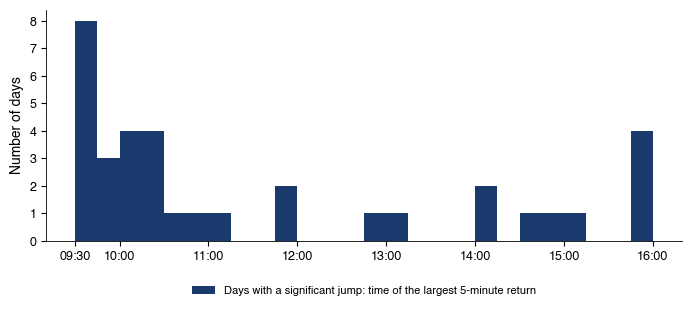

   saved ch9_sem_jump_times
b1_spy_jumps {'N': 1489, 'n5': 235, 'share5': 0.15782404298186703, 'exp5': 74.45, 'n1': 110, 'share1': 0.07387508394895903, 'exp1': 14.89, 'n0_1': 35, 'share0_1': 0.02350570852921424, 'exp0_1': 1.489, 'at10': 0.05714285714285714, 'at14': 0.05714285714285714, 'n_jump': 35, 'top': [{'date': '2021-08-27', 'z': 5.218990969338793, 'jshare': 0.49309151100370663, 'time': '10:05'}, {'date': '2022-01-03', 'z': 5.213766014936756, 'jshare': 0.46238027303735096, 'time': '09:50'}, {'date': '2025-08-25', 'z': 4.771238432226234, 'jshare': 0.4215899387016839, 'time': '16:00'}], 'jshare': 0.028357370498370525, 'z_mean': 0.49603864695663646, 'z_sd': 1.1431418238917002}
b2_btc_jumps {'N': 659, 'n': 67, 'share': 0.10166919575113809, 'share_we': 0.17587939698492464, 'share_wd': 0.06956521739130435, 'jshare': 0.018446058414483185, 'exp': 0.659, 'p_binom': 3.476994253285347e-109, 'bv_rv_we': 0.8972063027966776, 'bv_rv_wd': 0.9401696216050954, 'z_zero_share': 0.0073712274489967965}

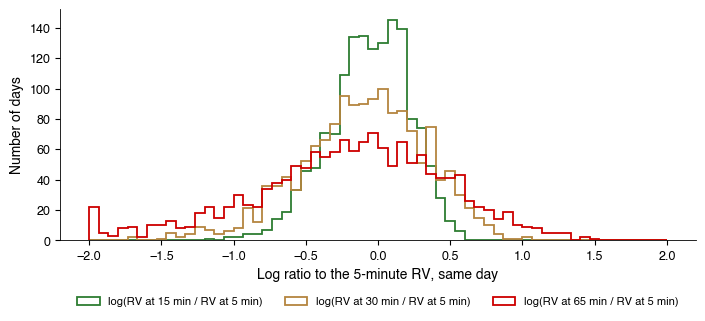

   saved ch9_sem_frequency
b3_frequency {'5': {'vol': 12.928990072875376, 'vol_sub': 12.928990072875376, 'ratio': 1.0, 'lo': 1.0, 'hi': 1.0, 'corr_next': 0.7271913183895193, 'sd_rel': 8.63403519237157e-18, 'corr_next_sub': 0.7271913183895193}, '15': {'vol': 12.877041835864654, 'vol_sub': 12.786755445874537, 'ratio': 0.9919802129006909, 'lo': 0.9543858443548825, 'hi': 1.0348045378738862, 'corr_next': 0.7093741658221016, 'sd_rel': 0.2790036869535568, 'corr_next_sub': 0.7223142260207475}, '30': {'vol': 12.754685769594197, 'vol_sub': 12.769192237004653, 'ratio': 0.9732184267668156, 'lo': 0.9333797195802198, 'hi': 1.0145931992755097, 'corr_next': 0.7011183192539961, 'sd_rel': 0.4295436961570873, 'corr_next_sub': 0.7155979050210395}, '65': {'vol': 12.757465080420126, 'vol_sub': 12.875860061522365, 'ratio': 0.9736426114565117, 'lo': 0.9131426982697611, 'hi': 1.0370022662748337, 'corr_next': 0.6426150385049014, 'sd_rel': 0.6808095886364927, 'corr_next_sub': 0.7006021033528963}}


b4_standardised {'spy': {'kz': 2.6541534328371674, 'kz_lo': 2.52702580131049, 'kz_hi': 2.784026230560209, 'ku': 15.732926393989384, 'ku_lo': 4.5932658683464025, 'ku_hi': 26.80164116458134, 'sdz': 1.053441554259807, 'jbz': 7.607467835613392, 'jbz_p': 0.022287396987105104, 'skz': 0.027426451973826867, 'N': 1489, 'tail3': 0.000671591672263264, 'tail3u': 0.011417058428475487}, 'btc': {'kz': 2.7693713230360335, 'kz_lo': 2.5835000090994313, 'kz_hi': 2.968632502091973, 'ku': 7.566126114846244, 'ku_lo': 4.311996692657657, 'ku_hi': 10.650279384521072, 'sdz': 0.9246390510859077, 'jbz': 3.3361907459200553, 'jbz_p': 0.18860594774995418, 'skz': 0.13068141755278073, 'N': 659, 'tail3': 0.0, 'tail3u': 0.015174506828528073}, 'normal_tail3': 0.002699796063260186}
b5_har_insample {'b': array([-0.07874716,  0.36202234,  0.33691474,  0.16739331]), 'se_nw': array([0.02658344, 0.03705921, 0.04823207, 0.04395403]), 'se_ols': array([0.0249223 , 0.03058534, 0.04872425, 0.04560402]), 'r2': np.float64(0.470308687

b6_week {'T': 1176, 'har': {'qlike': 0.21541874828025862, 'mse': 64.11945316071828, 'mz_b': np.float64(1.1158900121783057), 'mz_a': np.float64(-0.11658573084012158), 'mz_r2': np.float64(0.23671146011407296), 'mz_p': 0.47908654943948004, 'mz_se_b': np.float64(0.21395780553221505)}, 'garch': {'qlike': 0.22364090587731766, 'mse': 86.36711491295732, 'mz_b': np.float64(0.4807119452531513), 'mz_a': np.float64(2.5955358705730394), 'mz_r2': np.float64(0.16535111828308036), 'mz_p': 0.0013074765303249902, 'mz_se_b': np.float64(0.1463462205674037)}, 'dm_t': -0.7426600993593387, 'dm_p': 0.45768749255774077, 'pers_med': 0.9969851113764159, 'note_overlap': 'overlapping 5-day targets: HAC lags set by the rule of thumb'}
b7_harcj {'b': array([-0.18834515,  0.40073762,  0.24994824,  0.19978393,  0.19414882,
        0.27976111, -0.25956148]), 'se': array([0.02822227, 0.03362469, 0.04600447, 0.04634419, 0.08990812,
       0.12950452, 0.17372141]), 'r2': np.float64(0.46132745435282774), 'r2_base': np.floa

b8_rough {'rv_total': {'H': 0.1057501363262207, 'lo': 0.08160252456634043, 'hi': 0.12908895770883003}, 'rv_intraday': {'H': 0.12916283266645315, 'lo': 0.10287078377845359, 'hi': 0.15319951734651283}, 'bv': {'H': 0.12923596178442456, 'lo': 0.10294596729810425, 'hi': 0.15346476958849053}, 'rv30_sub': {'H': 0.1110394748075601, 'lo': 0.08550815541271035, 'hi': 0.13649170428724444}, 'sim_bm': 0.4638489951259916, 'sim_bm_noise': 0.18157012918203358}


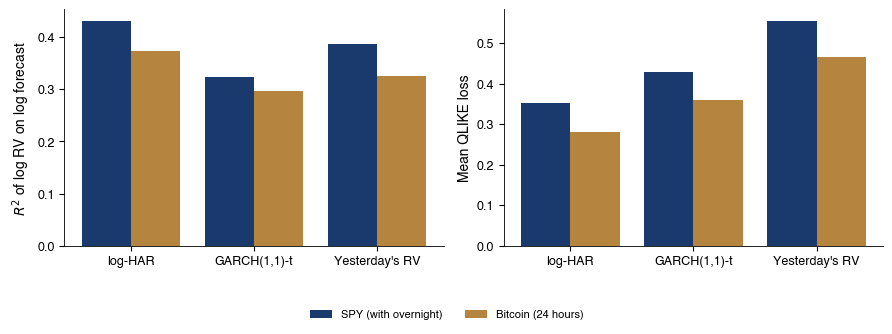

   saved ch9_sem_c1
C1 {'spy': {'T': 389, 'logHAR': {'r2': np.float64(0.33877312434104045), 'qlike': 0.35217560388194324, 'r2log': 0.43133835293140593}, 'GARCH-t': {'r2': np.float64(0.18816454229745383), 'qlike': 0.4288278621494189, 'r2log': 0.32260987251419193}, 'RW': {'r2': np.float64(0.35176541528642813), 'qlike': 0.5555843694796565, 'r2log': 0.3856208589609729}, 'gain_rw': 0.36611678940539627, 'gain_garch': 0.17874831612682685}, 'btc': {'T': 422, 'logHAR': {'r2': np.float64(0.3814203164276777), 'qlike': 0.28167048225356855, 'r2log': 0.3728477905018641}, 'GARCH-t': {'r2': np.float64(0.23192858630012203), 'qlike': 0.3603700084122623, 'r2log': 0.29554111637025354}, 'RW': {'r2': np.float64(0.3282361964634868), 'qlike': 0.46571630463834507, 'r2log': 0.3250405271343688}, 'gain_rw': 0.39518870297594255, 'gain_garch': 0.21838533818458528}, 'r2diff': -0.058490562429541815, 'r2diff_lo': -0.253293505300497, 'r2diff_hi': 0.16365873445134352, 'we': {'b_we': -1.030539186101036, 'se_we': 0.082025

ex_harq_shar {'harq': {'b': [np.float64(0.21692263011055385), np.float64(0.5423970880411779), np.float64(0.1727284721598824), np.float64(0.08778685485855581), np.float64(-0.002239674564998293)], 'se': [np.float64(0.1090175504225918), np.float64(0.2818322965200274), np.float64(0.12788922865366084), np.float64(0.06693068953587104), np.float64(0.002403861141258224)], 'r2': 0.32561856706063297, 'r2_har': 0.31463386422018225, 'bd_at': {'0.5': 0.541411330600974, '0.99': 0.5311795390047426}}, 'shar': {'b': [np.float64(0.259077313687187), np.float64(0.20822111795139317), np.float64(0.560450935551935), np.float64(0.24848720951992698), np.float64(0.11549255720874392)], 'se': [np.float64(0.07593429714421449), np.float64(0.1781412826351688), np.float64(0.2278589008305716), np.float64(0.11877326776704247), np.float64(0.0542920034289657)], 'r2': 0.3230446697106054, 'wald_pm': 0.8834686502608243, 'p_pm': 0.34725340088570045}, 'qlike': {'logHAR': 0.30982425810571296, 'HAR': 0.32635583427258796, 'GARCH

ex_gw_week {'gw': 1.3701890505973982, 'p': 0.504042582547264, 'T': 1171, 't_unc': 0.6091088753550046, 'p_unc': 0.5424522750868879, 'q_har': 0.2471165513928793, 'q_garch': 0.23230539506962872, 'win_har': 250, 'win_garch': 1000}
ex_rk_ratio {'ratio': 0.9518485395708459, 'lo': 0.9102511608639554, 'hi': 0.9874833265499506, 'H_med': 7.0}
ex_a8_mz {'a': 0.24176612525989988, 'b': 0.7046405329357701, 'se_a': 0.23098724061400286, 'se_b': 0.23819296598125608, 'cov': -0.05364473927847199, 'corr': -0.9750125724695164, 'wald': 2.0717032266126316, 'p': 0.35492399418876086, 'ta': 1.046664415823337, 'tb': -1.2400007945132703, 'dbar': -0.03271815935809545, 'se_d': 0.014215716705578894, 'dm_t': -2.3015483521316487, 'dm_p': 0.021360655629999992}
ex_a6_jensen {'1': 0.6366197723675815, '6': 0.9203884727313848, '78': 0.9936104199003668}


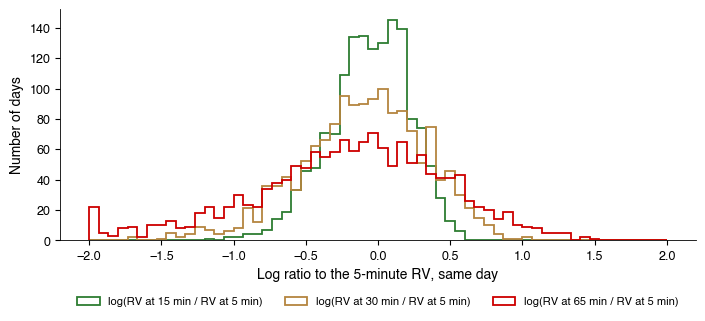

   saved ch9_sem_frequency


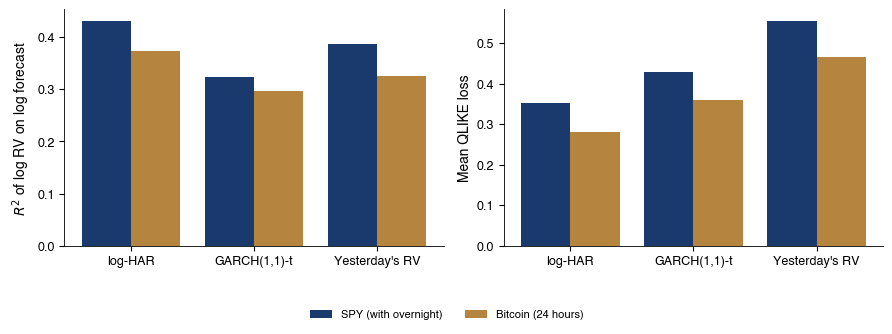

   saved ch9_sem_c1


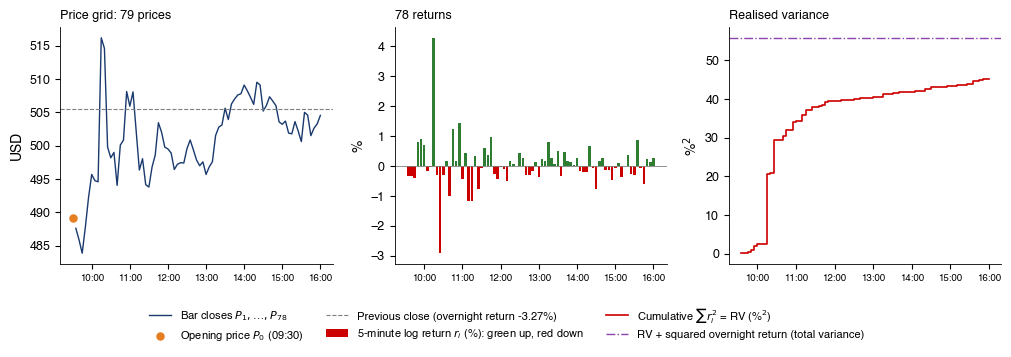

   saved ch9_sem_day
sc_day {'spy_days': 1489, 'spy_cols': 79, 'full': 1477, 'half': 12, 'other': 0, 'first': '2020-10-12', 'last': '2026-09-18', 'btc_days': 659, 'btc_cols': 289, 'btc_first': '2024-09-01', 'btc_last': '2026-09-17', 'p': [489.190002, 487.600006, 485.875], 'r': [-0.32555562429887885, -0.35440207398975687], 'p_last': 504.540008, 'n': 78, 'rv': 45.14579516498877, 'on': -3.267894978785783, 'total': 55.824932757362106}


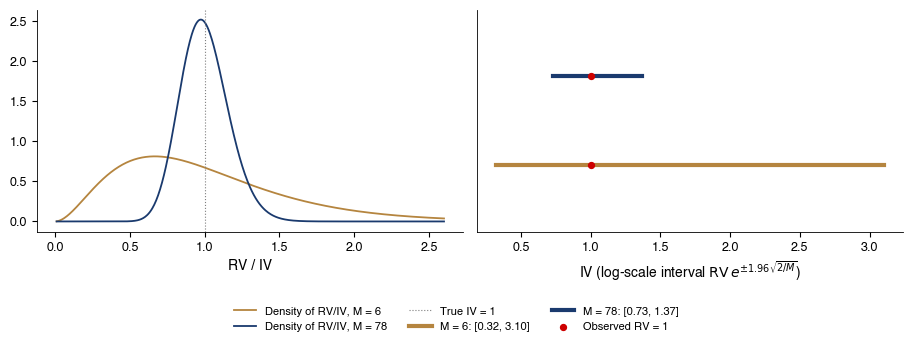

   saved ch9_sem_a1
sc_a1 {'cov6': 0.86679, 'cov78': 0.942325, 'lo6': np.float64(0.322514711216447), 'hi6': np.float64(3.100633754746391), 'lo78': np.float64(0.7306277510259088), 'hi78': np.float64(1.368686035530204)}


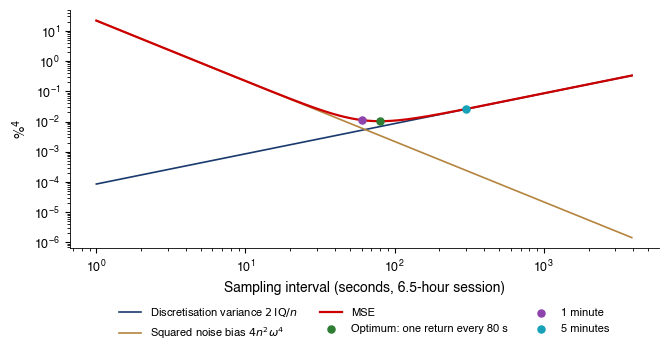

   saved ch9_sem_a3
sc_a3 {'5min': {'n': 78.0, 'bias': 0.015600000000000001, 'erv': 1.0156, 'mse': 0.02588438564102564, 'disc': 0.02564102564102564, 'bias2': 0.00024336}, '1min': {'n': 390.0, 'bias': 0.078, 'erv': 1.078, 'mse': 0.011212205128205128, 'disc': 0.005128205128205128, 'bias2': 0.006084}, '1s': {'n': 23400.0, 'bias': 4.680000000000001, 'erv': 5.680000000000001, 'mse': 21.90248547008547, 'disc': 8.547008547008547e-05, 'bias2': 21.9024}, 'opt': {'n': 292.4017738212865, 'bias': 0.0584803547642573, 'erv': 1.0584803547642574, 'mse': 0.010259855680060182, 'disc': 0.0068399037867067905, 'bias2': 0.0034199518933533913}}


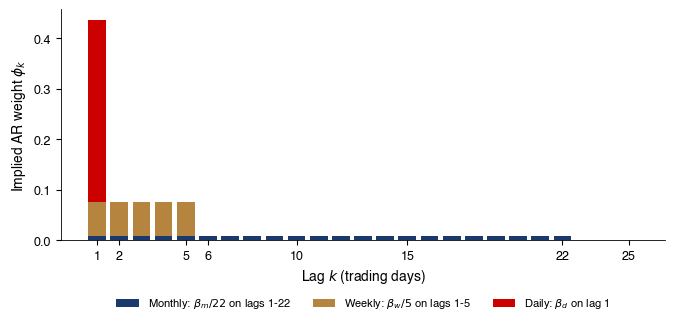

   saved ch9_sem_a5
sc_a5 {}


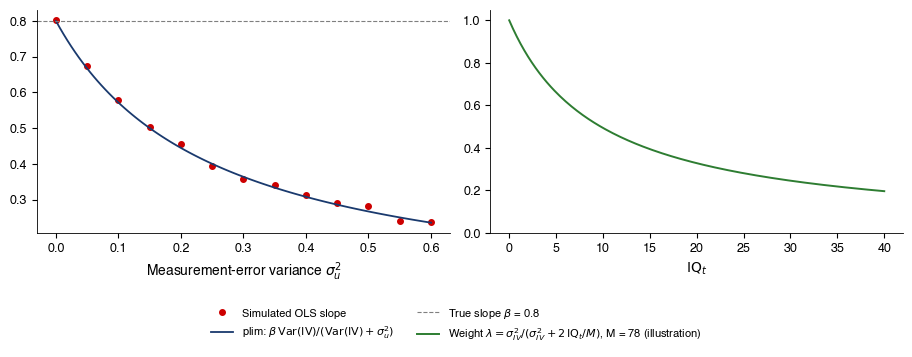

   saved ch9_sem_a7
sc_a7 {'viv': 0.25000000000000006, 'slope25': 0.3941539050758166, 'plim25': 0.40000000000000013}


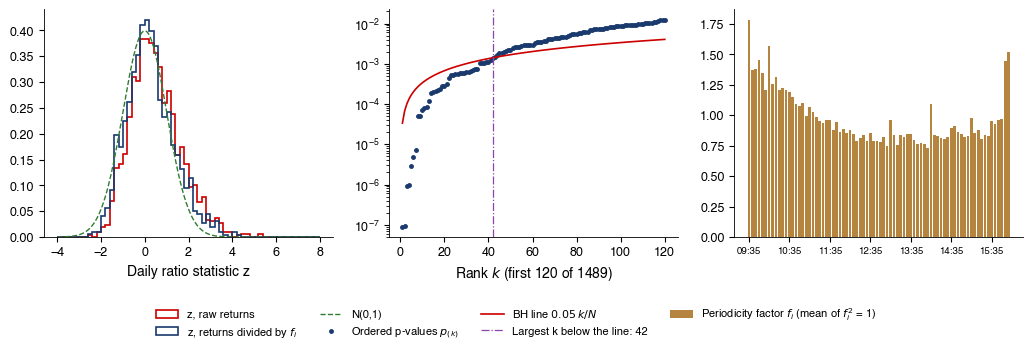

   saved ch9_sem_b1
sc_b1 {'day': '2021-08-27', 'M': 78, 'rv': 0.13543495820536391, 'bv': 0.06865313002115717, 'tq': 0.005388705009059199, 'tqbv': 1.1433092713593456, 'ratio': 0.49309151100370663, 'z': 5.218990969338793, 'p': 8.995026691900533e-08, 'J': 0.06678182818420675, 'rmax': 0.24312099709078439, 'rmax_share': 0.43642956006078065, 'kbh': 42, 'bh_thr': 0.0014103425117528543, 'p_k': 0.0013974127950574546, 'N': 1489}


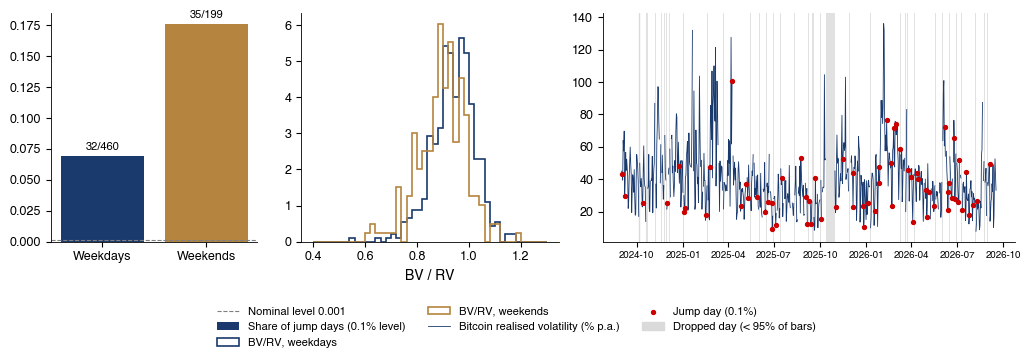

   saved ch9_sem_b2
sc_b2 {'n_wd': 460, 'n_we': 199, 'j_wd': 32, 'j_we': 35, 'missing': 88}


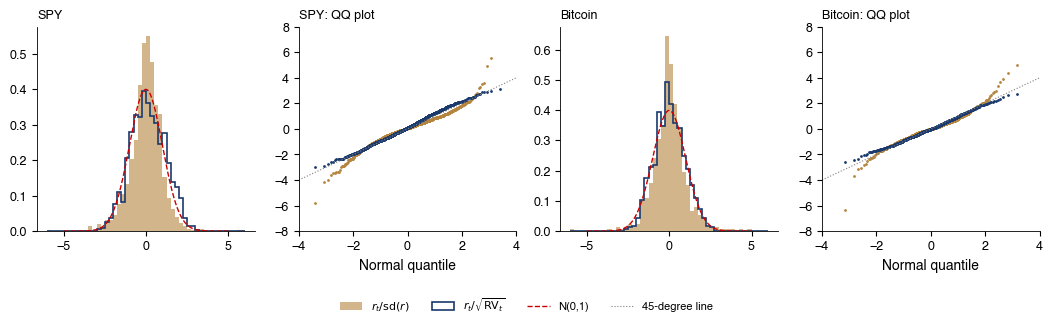

   saved ch9_sem_b4
sc_b4 {'day': '2025-04-07', 'r': 3.0896172773615156, 'rv': 45.14579516498878, 'z': 0.4598286550960912, 'kbench': 2.925}


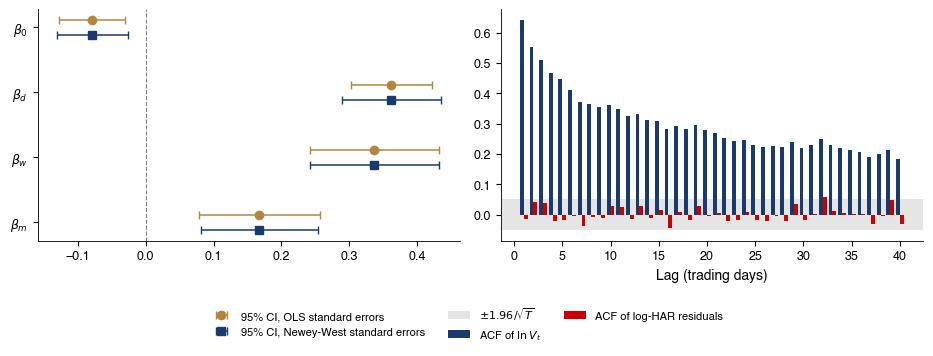

   saved ch9_sem_b5
sc_b5 {'day': '2025-04-08', 'y': 2.976124797646052, 'xd': 4.022220593199963, 'xw': 2.0682599860357205, 'xm': 0.6117748503537999, 'fit': 2.1766208529894966, 'T': 1467, 'N': 1489, 'ac_e1': -0.014008979328322135, 'ac_y1': 0.6427938378532413}


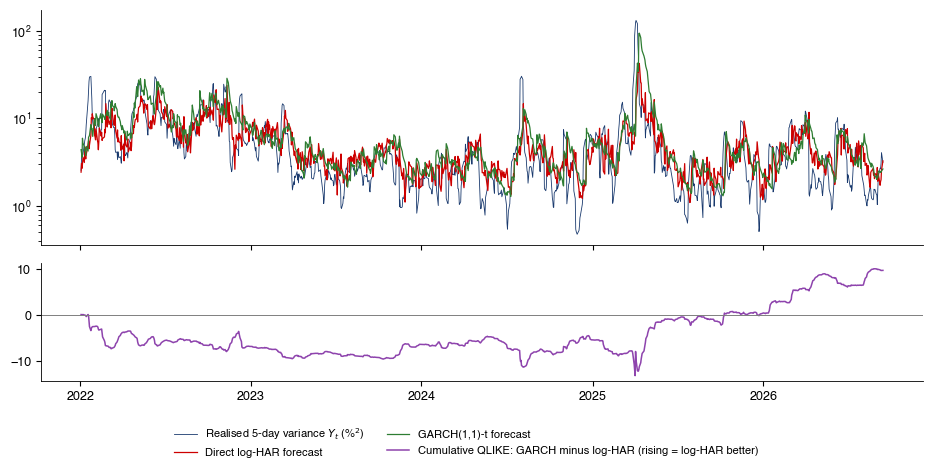

   saved ch9_sem_b6
sc_b6 {'cum_end': 9.669257334141445, 'first': '2022-01-03', 'last': '2026-09-14'}


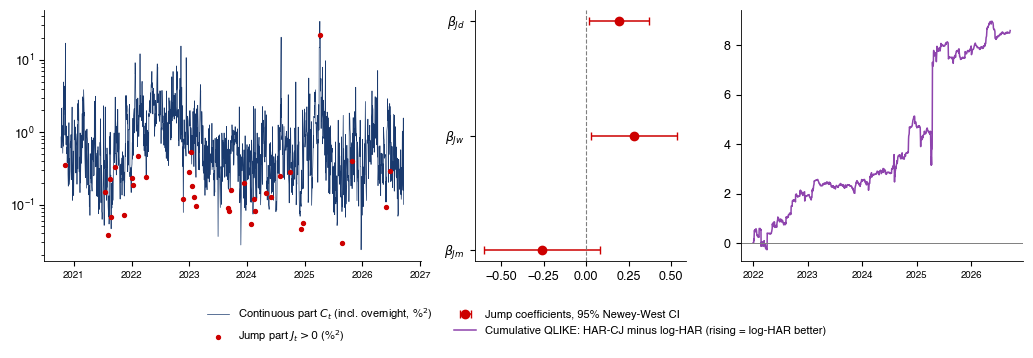

   saved ch9_sem_b7
sc_b7 {'n_jump_days': 35, 'cum_end': 8.585205519497741}


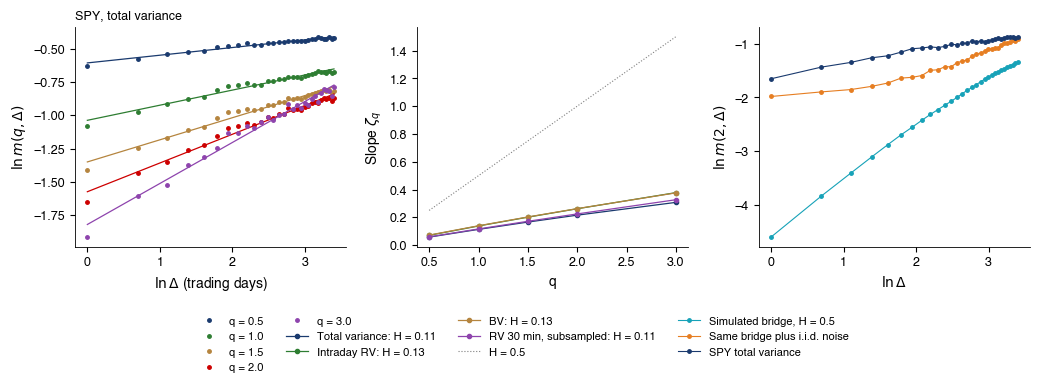

   saved ch9_sem_b8
sc_b8 {'m21': 0.19160701454712906, 'zeta2': 0.21555183665551336, 'icpt2': -1.5733144207649703, 'n_pairs1': 1488}


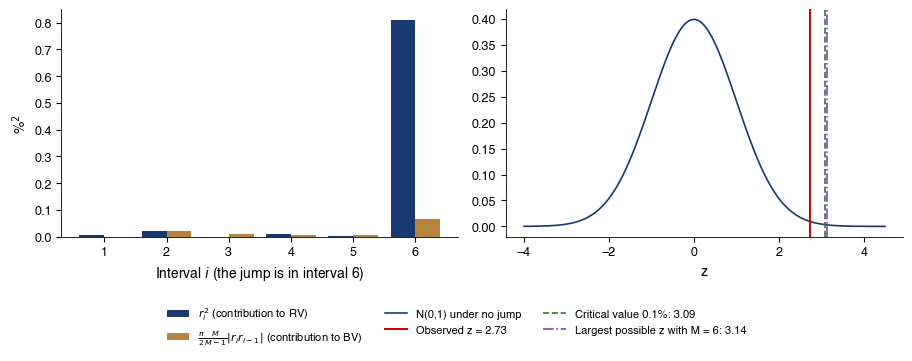

   saved ch9_sem_a2


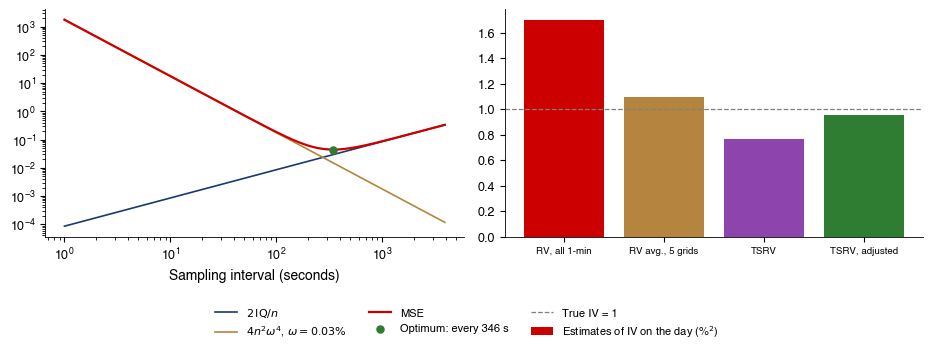

   saved ch9_sem_a4


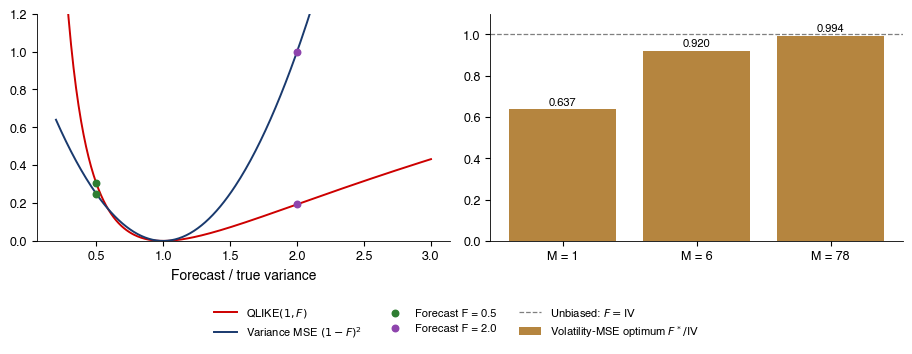

   saved ch9_sem_a6


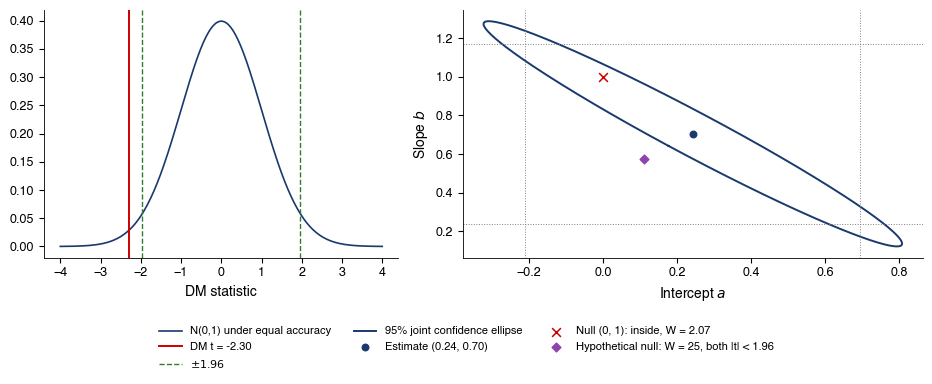

   saved ch9_sem_a8


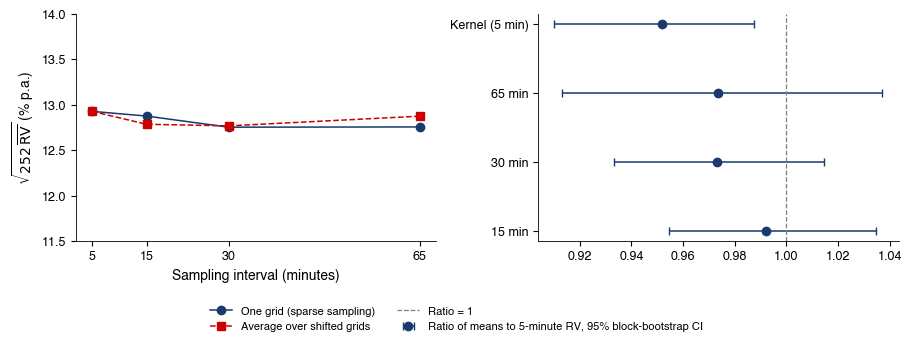

   saved ch9_sem_b3


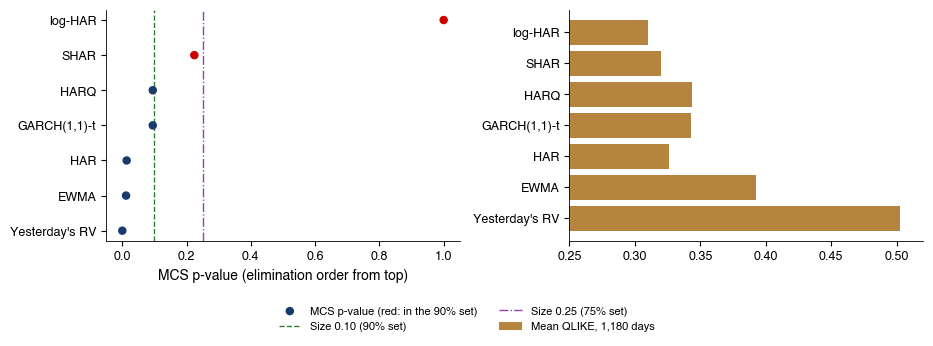

   saved ch9_sem_b9


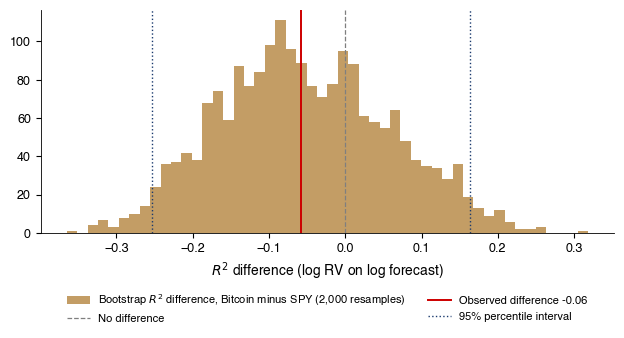

   saved ch9_sem_c1_boot
{'bvc': [0.0, 0.02261946710584651, 0.00848230016469244, 0.005654866776461627, 0.007539822368615503, 0.06785840131753954]} {'om2_oracle': 0.0008974358974358973, 'om2_all': 0.0021794871794871794} {} {'hyp_a': 0.10865854410689171, 'hyp_b': 0.575661218965907, 'hyp_ta': -0.5762551247384309, 'hyp_tb': -0.5414908598938758} {} {'order': ['RW', 'EWMA', 'HAR', 'GARCH-t', 'HARQ', 'SHAR', 'logHAR']} {'lo': -0.253293505300497, 'hi': 0.16365873445134352, 'cal_days': 567, 'spy_T': 389, 'btc_T': 422}


In [8]:
for f in [a1_rv_bv, a2_jump, a3_noise, a4_tsrv, a5_har, a6_losses, a7_har2, a8_dm]:
    print(f.__name__, f())
for f in [b1_spy_jumps, b2_btc_jumps, b3_frequency, b4_standardised, b5_har_insample, b6_week, b7_harcj, b8_rough]:
    print(f.__name__, f())
F, y = oos_forecasts(RVT_SPY, D_SPY, OOS_SPY, False)
Fb, yb = oos_forecasts(RV_BTC, D_BTC, OOS_BTC, True)
F.assign(proxy=y).to_csv('ch9_forecasts_spy.csv')
Fb.assign(proxy=yb).to_csv('ch9_forecasts_btc.csv')
print('C1', c1_predictability())
for f in [ex_jump_inference, ex_har_ar22, ex_harq_shar, ex_gw_week, ex_rk_ratio, ex_a8_mz, ex_a6_jensen]:
    print(f.__name__, f())
R_ = {'A2': a2_jump(), 'A4': a4_tsrv(), 'XA6': ex_a6_jensen(), 'XA8': ex_a8_mz(), 'B3': b3_frequency(),
      'XRK': ex_rk_ratio(), 'XQS': ex_harq_shar(), 'C1': c1_predictability()}
for f in [sc_day, sc_a1, sc_a3, sc_a5, sc_a7, sc_b1, sc_b2, sc_b4, sc_b5, sc_b6, sc_b7, sc_b8]:
    print(f.__name__, f())
print(sc_a2(R_['A2']), sc_a4(R_['A4']), sc_a6(R_['XA6']), sc_a8(R_['XA8']), sc_b3(R_['B3'], R_['XRK']),
      sc_b9(R_['XQS']), sc_c1(R_['C1']))

![ch9_sem_jump_times](./ch9_sem_jump_times.png)

Output: `ch9_sem_jump_times.pdf`

![ch9_sem_frequency](./ch9_sem_frequency.png)

Output: `ch9_sem_frequency.pdf`

![ch9_sem_c1](./ch9_sem_c1.png)

Output: `ch9_sem_c1.pdf`

![ch9_sem_day](./ch9_sem_day.png)

Output: `ch9_sem_day.pdf`

![ch9_sem_a1](./ch9_sem_a1.png)

Output: `ch9_sem_a1.pdf`

![ch9_sem_a2](./ch9_sem_a2.png)

Output: `ch9_sem_a2.pdf`

![ch9_sem_a3](./ch9_sem_a3.png)

Output: `ch9_sem_a3.pdf`

![ch9_sem_a4](./ch9_sem_a4.png)

Output: `ch9_sem_a4.pdf`

![ch9_sem_a5](./ch9_sem_a5.png)

Output: `ch9_sem_a5.pdf`

![ch9_sem_a6](./ch9_sem_a6.png)

Output: `ch9_sem_a6.pdf`

![ch9_sem_a7](./ch9_sem_a7.png)

Output: `ch9_sem_a7.pdf`

![ch9_sem_a8](./ch9_sem_a8.png)

Output: `ch9_sem_a8.pdf`

![ch9_sem_b1](./ch9_sem_b1.png)

Output: `ch9_sem_b1.pdf`

![ch9_sem_b2](./ch9_sem_b2.png)

Output: `ch9_sem_b2.pdf`

![ch9_sem_b3](./ch9_sem_b3.png)

Output: `ch9_sem_b3.pdf`

![ch9_sem_b4](./ch9_sem_b4.png)

Output: `ch9_sem_b4.pdf`

![ch9_sem_b5](./ch9_sem_b5.png)

Output: `ch9_sem_b5.pdf`

![ch9_sem_b6](./ch9_sem_b6.png)

Output: `ch9_sem_b6.pdf`

![ch9_sem_b7](./ch9_sem_b7.png)

Output: `ch9_sem_b7.pdf`

![ch9_sem_b8](./ch9_sem_b8.png)

Output: `ch9_sem_b8.pdf`

![ch9_sem_b9](./ch9_sem_b9.png)

Output: `ch9_sem_b9.pdf`

![ch9_sem_c1_boot](./ch9_sem_c1_boot.png)

Output: `ch9_sem_c1_boot.pdf`